# Практичне завдання 2: Багатокласова логістична регресія та федеративне навчання

**Студент:** Олександр Гріджак  
**Група:** ФІ-43  
**Репозиторій курсу:** [OleksandrHridzhak/ml-4](https://github.com/OleksandrHridzhak/ml-4)  

---

## Мета роботи
1. Зрозуміти математичну та алгоритмічну архітектуру багатокласової логістичної регресії (Softmax Regression).
2. Реалізувати модель з нуля засобами бібліотеки `numpy`: чисельно стабільний Softmax, функція втрат крос-ентропії (Log-Loss) з Ridge-регуляризацією, векторизовані аналітичні градієнти без неефективних циклів `for` по семплах, міні-батчевий градієнтний спуск (Mini-batch GD).
3. Дослідити архітектуру та математичні принципи **федеративного навчання (Federated Learning)**: розмежування доступу до даних між сервером та клієнтами, симуляція алгоритму **FedAvg** (Federated Averaging).
4. Здійснити коректне розбиття даних на Global Test (15%), Global Validation (15%) та FL Train Pool (70%) без витоку інформації (*Data Leakage*).
5. Дослідити розбиття пулу тренувальних даних на клієнтські вибірки:
   - **IID-розподіл** (Independent and Identically Distributed);
   - **Non-IID розподіл** за допомогою розподілу Діріхле Dir(α) для α ∈ {5.0, 1.0, 0.3}.
6. Порівняти три класи моделей: локальні моделі клієнтів (Local Only), глобальну федеративну модель (FedAvg) та централізовану модель (Centralized Baseline).
7. Провести обов'язкові експерименти:
   - Вплив ступеня неоднорідності даних (Non-IID skewness через α Діріхле);
   - Вплив кількості локальних епох (E ∈ {1, 5, 10}) та аналіз явища **клієнтського дрейфу (Client Drift)**.
8. Надати вичерпні відповіді на 17 теоретичних питань з методичних вказівок.



### 1. Рекомендований датасет

Для виконання роботи використано рекомендований **Dry Bean Dataset** (Kaggle / UCI Machine Learning Repository, ID 602).
* **Джерело:** [Kaggle Dry Bean Dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset) / UCI ID 602.
* **Цільова змінна:** `Class` — сорт квасолі (7 класів: `DERMASON`, `SIRA`, `SEKER`, `HOROZ`, `CALI`, `BARBUNYA`, `BOMBAY`).
* **Кількість об'єктів:** 13 611 зерен.
* **Ознаки:** 16 неперервних числових фізико-морфологічних характеристик:
  - 12 геометричних вимірів: `Area`, `Perimeter`, `MajorAxisLength`, `MinorAxisLength`, `AspectRation`, `Eccentricity`, `ConvexArea`, `EquivDiameter`, `Extent`, `Solidity`, `roundness`, `Compactness`.
  - 4 коефіцієнти форми: `ShapeFactor1`, `ShapeFactor2`, `ShapeFactor3`, `ShapeFactor4`.

#### Чому даний датасет ідеально підходить для федеративного навчання:
1. **Багатокласова природа (7 класів):** дозволяє моделювати реалістичні Non-IID сценарії за допомогою розподілу Діріхле, коли окремі агропідприємства вирощують лише обмежений асортимент сортів.
2. **Достатня вибірка (13 611 об'єктів):** забезпечує можливість розбиття пулу між K = 5 клієнтами (по 1000–3000 семплів на клієнта), зберігаючи високу статистичну значущість.
3. **Реальний сценарій конфіденційності (Data Privacy):** у сільськогосподарській аналітиці фермерські кооперативи або сертифікаційні лабораторії володіють даними про свій врожай і не бажають розкривати комерційні обсяги виробництва конкурентам чи центральному серверу, але зацікавлені у спільній глобальній моделі ідентифікації сортів високої точності.


In [1]:
# Імпорт необхідних бібліотек для математичних розрахунків, маніпуляцій з даними та візуалізації
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score, log_loss,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Налаштування стилів графіків для високої якості відображення
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# Фіксація випадкового стану для повної відтворюваності
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Бібліотеки успішно завантажено. Random Seed зафіксовано на", RANDOM_SEED)


Бібліотеки успішно завантажено. Random Seed зафіксовано на 42


In [2]:
# Завантаження датасету Dry Bean Dataset
csv_filename = 'Dry_Bean_Dataset.csv'
df = pd.read_csv(csv_filename)

print(f"Форма датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print("\nПерші 5 рядків датасету:")
df.head()


Форма датасету: 13611 рядків, 17 колонок

Перші 5 рядків датасету:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### 2. Етапи виконання

### 2.1 Етап 1. Дослідження даних (EDA), відбір ознак та попередня обробка

#### 1. Первинний аналіз даних:
* Перевірка типів даних та відсутності пропущених значень;
* Аналіз частотного розподілу цільової змінної `Class`;
* Описові статистики числових характеристик;
* Дослідження кореляцій між ознаками та мультиколінеарності.


In [3]:
# Аналіз типів даних та наявності пропущених значень
data_info = pd.DataFrame({
    'Тип даних': df.dtypes,
    'Кількість пропусків': df.isnull().sum(),
    'Частка пропусків (%)': (df.isnull().sum() / len(df)) * 100,
    'Унікальних значень': df.nunique()
})
print("Зведена інформація про колонки датасету:")
display(data_info)

# Перевірка наявності повних дублікатів
duplicates_count = df.duplicated().sum()
print(f"\nКількість дублікатів у вибірці: {duplicates_count} ({duplicates_count / len(df) * 100:.2f}%)")
if duplicates_count > 0:
    print("Примітка: У фізичних вимірах квасолі незначна кількість дублікатів виникає через округлення оптичних сенсорів.")


Зведена інформація про колонки датасету:


,Тип даних,Кількість пропусків,Частка пропусків (%),Унікальних значень
Area,float64,0,0.0,12011
Perimeter,float64,0,0.0,13413
MajorAxisLength,float64,0,0.0,13543
MinorAxisLength,float64,0,0.0,13543
AspectRation,float64,0,0.0,13543
Eccentricity,float64,0,0.0,13543
ConvexArea,float64,0,0.0,12066
EquivDiameter,float64,0,0.0,12011
Extent,float64,0,0.0,13535
Solidity,float64,0,0.0,13526



Кількість дублікатів у вибірці: 68 (0.50%)
Примітка: У фізичних вимірах квасолі незначна кількість дублікатів виникає через округлення оптичних сенсорів.


Розподіл класів у датасеті:


,Кількість,Частка (%)
Class,,
DERMASON,3546,26.05
SIRA,2636,19.37
SEKER,2027,14.89
HOROZ,1928,14.17
CALI,1630,11.98
BARBUNYA,1322,9.71
BOMBAY,522,3.84


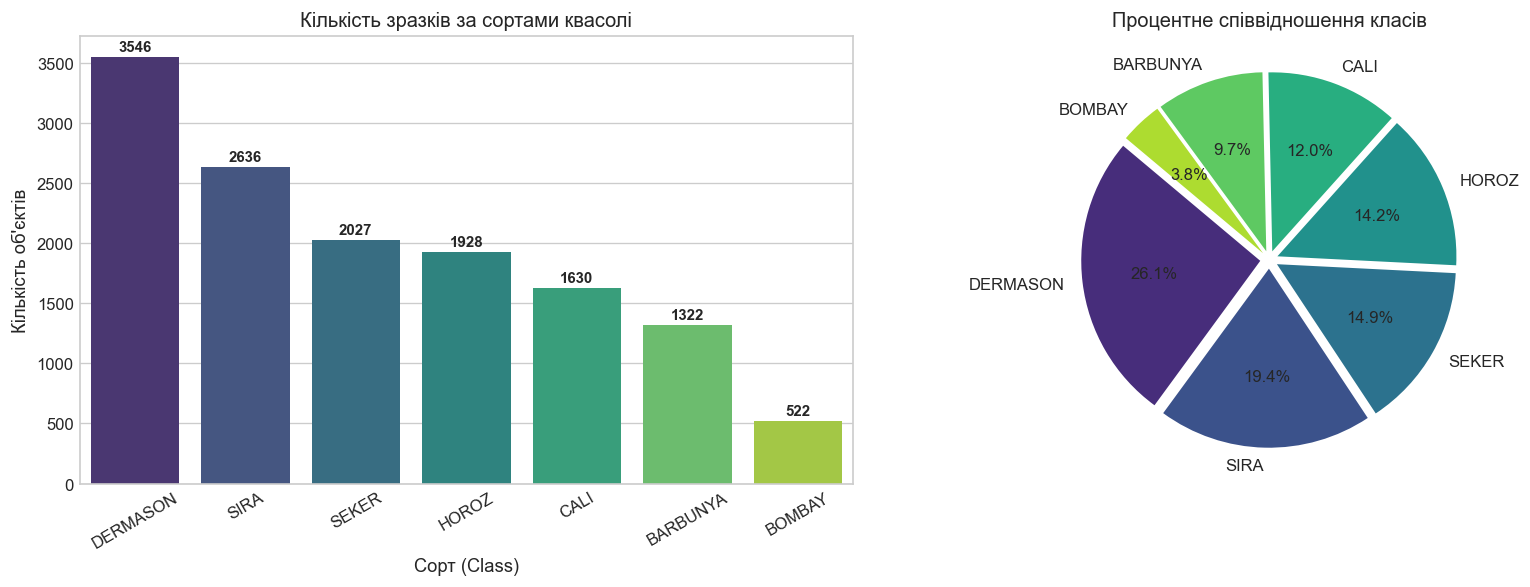

In [4]:
# Аналіз розподілу цільової змінної Class
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
target_dist_df = pd.DataFrame({'Кількість': class_counts, 'Частка (%)': class_pct.round(2)})

print("Розподіл класів у датасеті:")
display(target_dist_df)

# Візуалізація розподілу класів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Стовпчикова діаграма
colors = sns.color_palette('viridis', len(class_counts))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette=colors)
axes[0].set_title('Кількість зразків за сортами квасолі')
axes[0].set_xlabel('Сорт (Class)')
axes[0].set_ylabel('Кількість об\'єктів')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, f"{v}", ha='center', fontweight='bold', fontsize=9)

# Кругова діаграма
axes[1].pie(
    class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
    startangle=140, colors=colors, explode=[0.05]*len(class_counts)
)
axes[1].set_title('Процентне співвідношення класів')

plt.tight_layout()
plt.show()


In [5]:
# Описові статистики числових ознак
feature_cols = [c for c in df.columns if c != 'Class']
desc_stats = df[feature_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']

print("Описові статистики 16 морфологічних ознак:")
display(desc_stats.round(3))


Описові статистики 16 морфологічних ознак:


,mean,std,min,25%,50%,75%,max,range,IQR
Area,53048.285,29324.096,20420.000,36328.000,44652.000,61332.000,254616.000,234196.000,25004.000
Perimeter,855.283,214.290,524.736,703.523,794.941,977.213,1985.370,1460.634,273.690
MajorAxisLength,320.142,85.694,183.601,253.304,296.883,376.495,738.860,555.259,123.191
MinorAxisLength,202.271,44.970,122.513,175.848,192.432,217.032,460.198,337.686,41.184
AspectRation,1.583,0.247,1.025,1.432,1.551,1.707,2.430,1.405,0.275
Eccentricity,0.751,0.092,0.219,0.716,0.764,0.810,0.911,0.692,0.095
ConvexArea,53768.200,29774.916,20684.000,36714.500,45178.000,62294.000,263261.000,242577.000,25579.500
EquivDiameter,253.064,59.177,161.244,215.068,238.438,279.446,569.374,408.131,64.378
Extent,0.750,0.049,0.555,0.719,0.760,0.787,0.866,0.311,0.068
Solidity,0.987,0.005,0.919,0.986,0.988,0.990,0.995,0.075,0.004


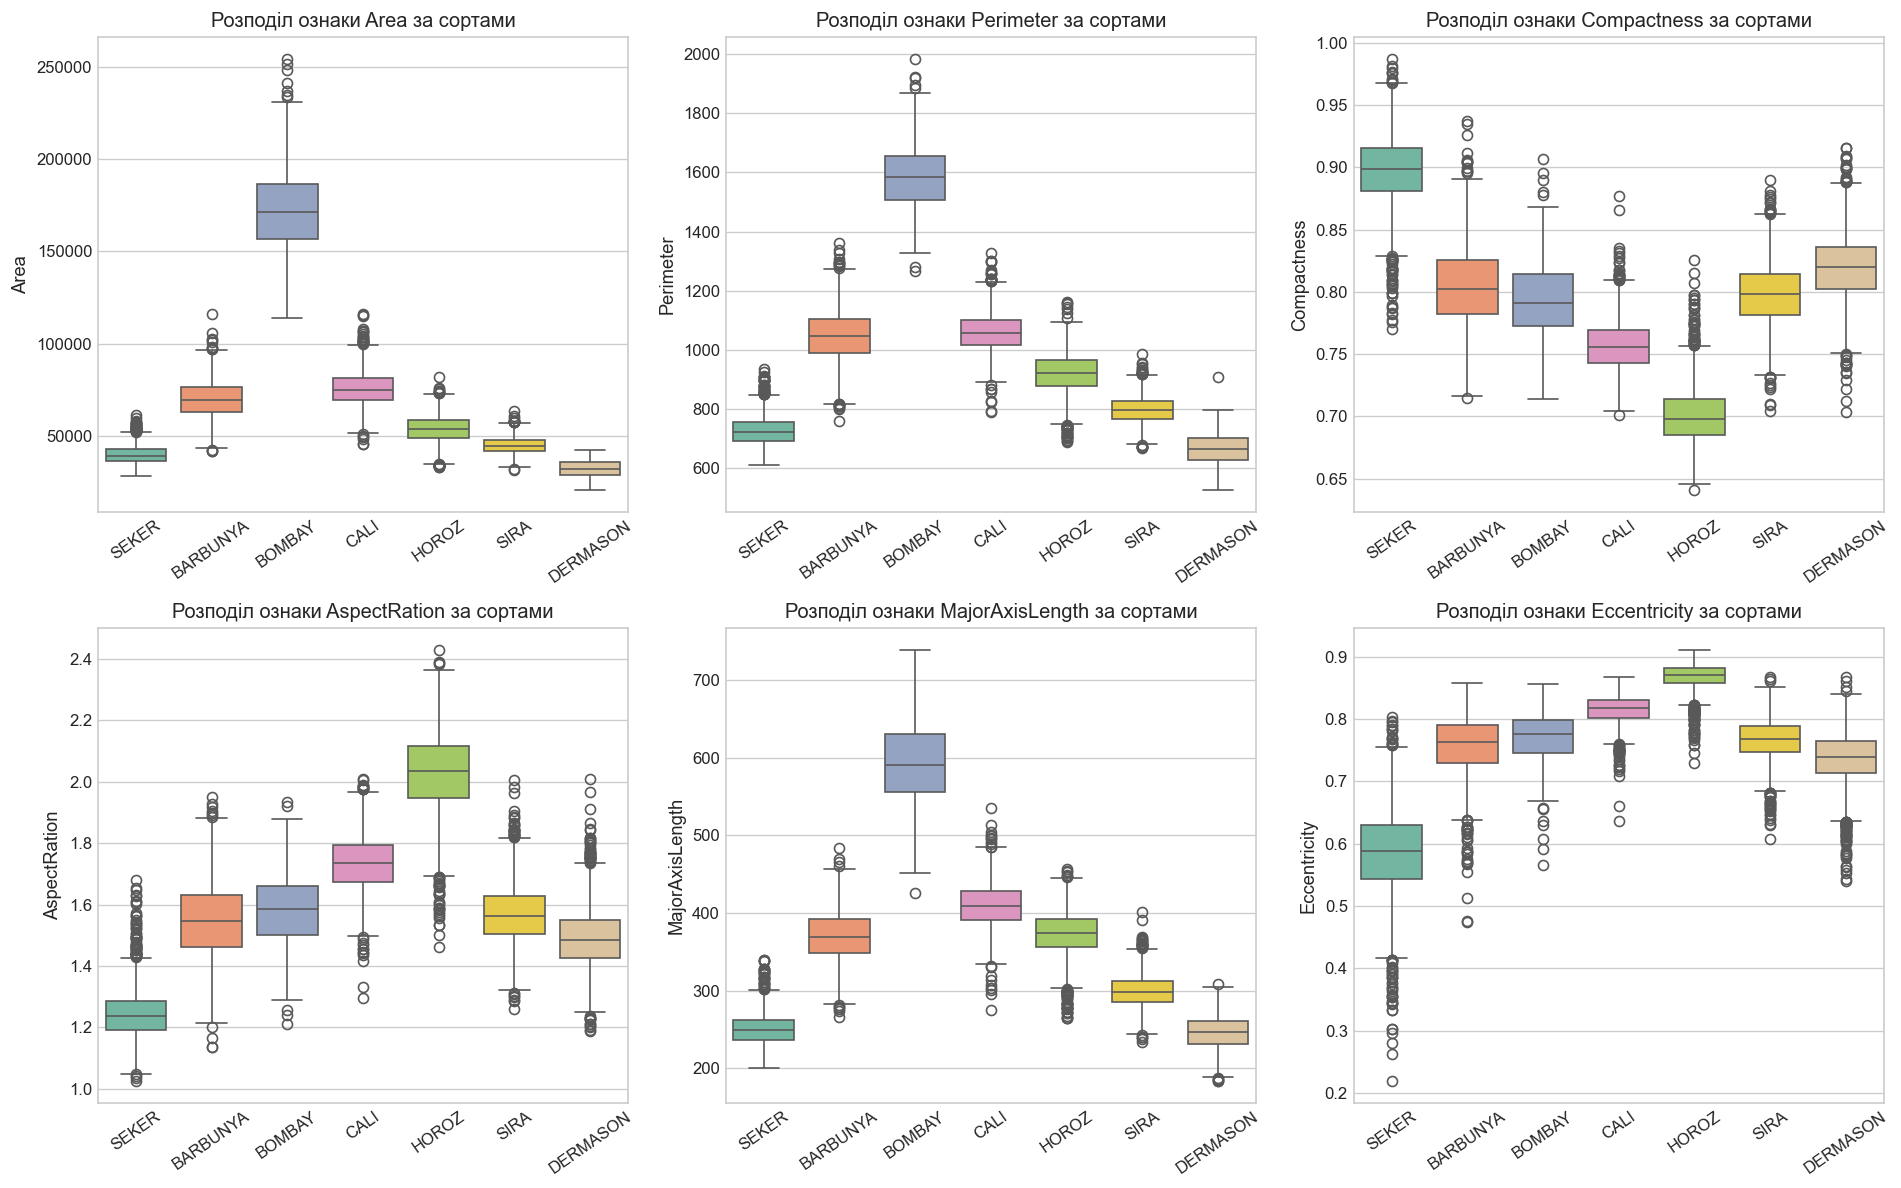

In [6]:
# Візуалізація розподілу ключових ознак залежно від сорту квасолі
key_features = ['Area', 'Perimeter', 'Compactness', 'AspectRation', 'MajorAxisLength', 'Eccentricity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='Class', y=feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Розподіл ознаки {feat} за сортами')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


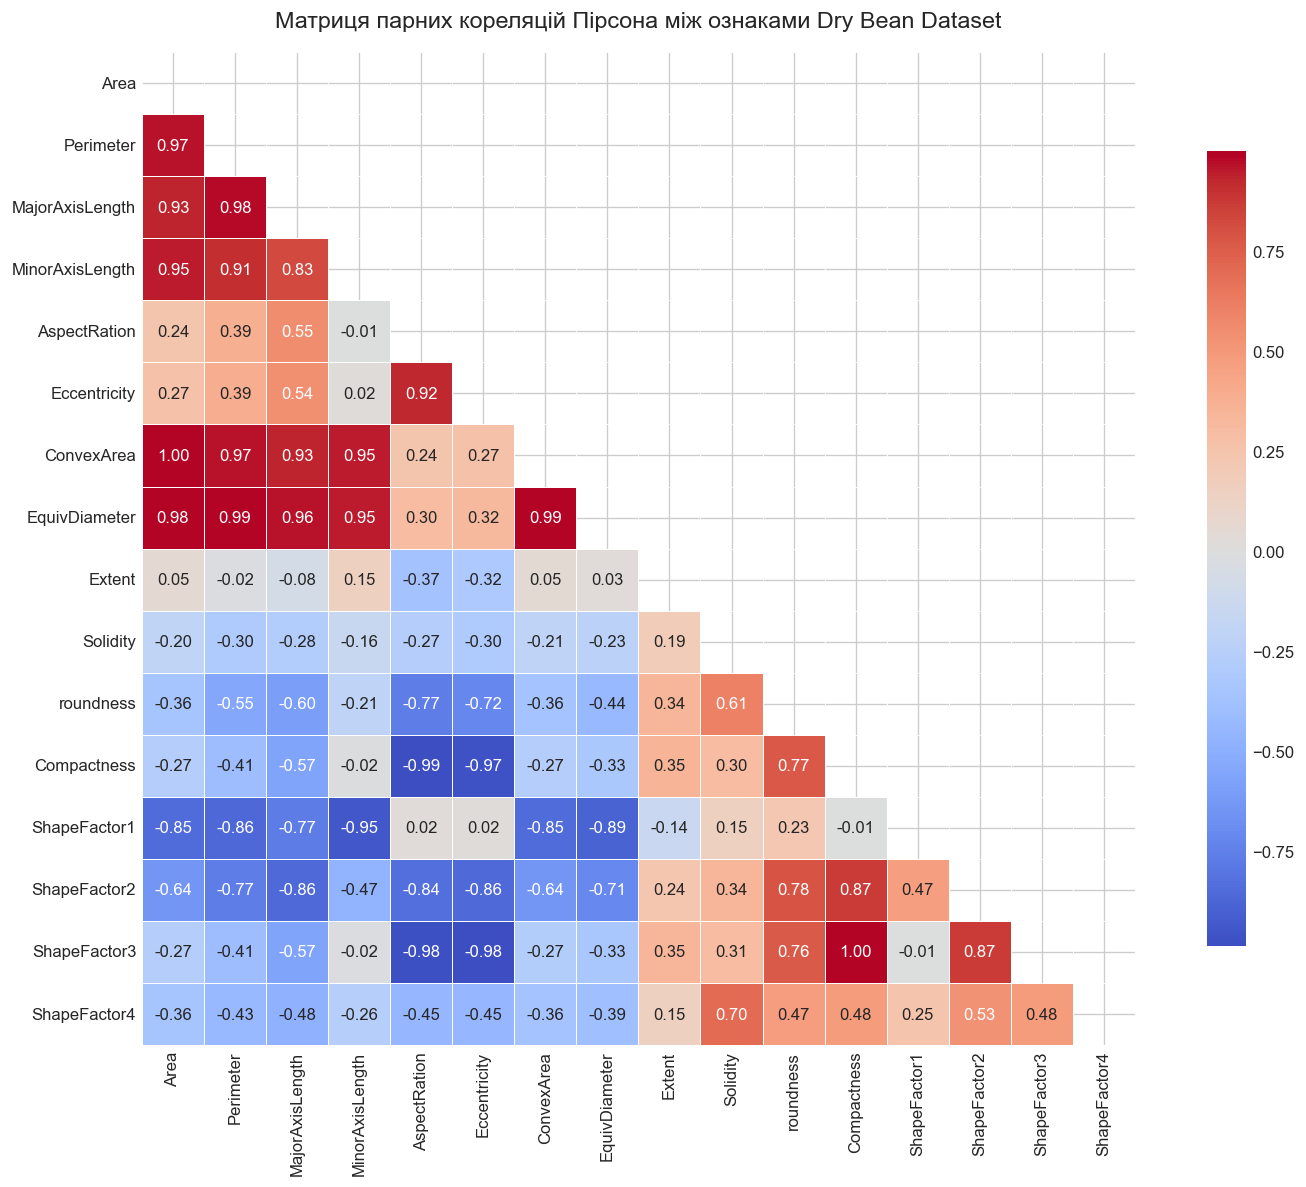

Пари ознак із дуже сильною кореляцією (|r| >= 0.90):


,Ознака 1,Ознака 2,Кореляція r
3,Area,ConvexArea,0.999939
20,Compactness,ShapeFactor3,0.998686
8,Perimeter,EquivDiameter,0.991380
15,AspectRation,Compactness,-0.987687
19,ConvexArea,EquivDiameter,0.985226
4,Area,EquivDiameter,0.984968
18,Eccentricity,ShapeFactor3,-0.981058
16,AspectRation,ShapeFactor3,-0.978592
5,Perimeter,MajorAxisLength,0.977338
17,Eccentricity,Compactness,-0.970313


In [7]:
# Кореляційна матриця між числовими ознаками
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Матриця парних кореляцій Пірсона між ознаками Dry Bean Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Виявлення пар ознак із майже функціональною мультиколінеарністю (|r| > 0.90)
strong_corrs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.90:
            strong_corrs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

strong_corr_df = pd.DataFrame(strong_corrs, columns=['Ознака 1', 'Ознака 2', 'Кореляція r']).sort_values(
    by='Кореляція r', key=abs, ascending=False
)
print("Пари ознак із дуже сильною кореляцією (|r| >= 0.90):")
display(strong_corr_df)


#### Аналітичний звіт та висновки щодо EDA та відбору ознак

* **Що показано:**
  1. Розподіл 7 класів у датасеті є помірно незбалансованим: переважають класи `DERMASON` (26.05%) та `SIRA` (19.37%), тоді як клас `BOMBAY` є найменшим (3.84%). Це підтверджує необхідність використання зважених та макро-метрик (`Macro-F1`, `Balanced Accuracy`).
  2. Всі 16 вхідних характеристик є числовими неперервними величинами без жодного пропущеного значення (`0 missing`).
  3. Матриця кореляцій показує колосальну мультиколінеарність між масштабними характеристиками: `Area` і `ConvexArea` мають кореляцію r = 1.00, `Perimeter` і `MajorAxisLength` r = 0.98, `EquivDiameter` і `Area` r = 0.99. Крім того, коефіцієнти форми `Compactness` та `ShapeFactor3` мають кореляцію r = 1.00.

* **Яка закономірність спостерігається:**
  Сорти квасолі чітко розпадаються на геометричні кластери: `BOMBAY` має найбільшу площу та периметр (гігантські боби); `HOROZ` має максимальний `AspectRation` (видовжена форма); `SEKER` вирізняється найбільшою округлістю `roundness` та `Compactness`.

* **Чому так відбувається:**
  Фізично насіння різних ботанічних сортів квасолі має спадкові біологічні норми росту та форми: довжина, співвідношення осей та опуклість є прямими генетичними маркерами сорту.

* **Вплив на вибір моделі та регуляризації:**
  Оскільки між ознаками спостерігається майже функціональна мультиколінеарність (|r| > 0.95), звичайна логістична регресія без регуляризації призведе до вибуху норм коефіцієнтів W та погано обумовленої матриці Гессе. Відтак, **Ridge-регуляризація (L2-штраф (λ / 2) · ||W||_F²) є критично необхідною** для стабілізації навчання як у централізованому режимі, так і при агрегації ваг у FedAvg.



### 2.1.3 Розбиття вибірки та теоретичне обґрунтування

Відповідно до регламенту практики, формуємо 3 ізольовані множини:
1. **Global Test (15%):** контрольна стратифікована вибірка. Зберігається на сервері та використовується **лише один раз** для фінальної об'єктивної оцінки узагальнюючої здатності моделі.
2. **Global Validation (15%):** стратифікована вибірка. Зберігається на сервері, слугує для моніторингу раундів федеративного навчання, підбору гіперпараметрів та запобігання перенавчанню. Жоден клієнт не має до неї доступу.
3. **FL Train Pool (70%):** пул тренувальних даних, який у наступних кроках буде розподілений між клієнтами для симуляції федеративного навчання.

---

> #### **Відповідь на обов'язкове теоретичне питання:**
> **Питання:** Чому ми повинні розбити дані до, а не після масштабування, кодування або інших операцій, які навчаються на даних? Поясніть термін *Data Leakage*.
>
> **Відповідь:**
> **Data Leakage (витік даних)** — це методологічна помилка в машинному навчанні, коли інформація з тестової або валідаційної вибірки ненавмисно потрапляє в процес навчання моделі або підготовки даних.
>
> Якщо обчислювати статистики масштабування (математичне сподівання μ та дисперсію σ² для StandardScaler або мінімум і максимум для MinMaxScaler) на всьому датасеті **до розбиття**, то інформація про глобальний розподіл тесту стане відомою моделі під час тренування. У результаті:
> 1. Модель отримує оптимістично занижені оцінки похибки та штучно завищену точність на тесті;
> 2. У реальних промислових умовах на нових невідомих спостереженнях (Out-of-Sample) якість моделі різко падає, оскільки модель спиралася на статистичні параметри, яких насправді не повинно було бути на етапі навчання.
>
> **Золоте правило ML:** Усі перетворення, які навчаються на даних (обчислення μ, σ, кодування категорій, відбір ознак), повинні підбиратися **суворо і виключно на тренувальній множині (FL Train Pool)**, а потім без змін застосовуватися до валідаційної та тестової множин.



In [8]:
# Реалізація коректного стратифікованого розбиття на 3 множини
X_all = df[feature_cols].values
y_str_all = df['Class'].values

# Кодування цільової змінної у числові мітки 0..6
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_str_all)
class_names = label_encoder.classes_
n_classes = len(class_names)

# 1. Виділяємо FL Train Pool (70%) та тимчасову вибірку (30%) зі стратифікацією за класами
X_train_pool, X_temp, y_train_pool, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_SEED, stratify=y_all
)

# 2. Тимчасову вибірку (30%) ділимо порівну на Global Validation (15%) та Global Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

split_summary = pd.DataFrame({
    'Множина даних': ['FL Train Pool', 'Global Validation', 'Global Test', 'Разом'],
    'Кількість зразків': [len(y_train_pool), len(y_val), len(y_test), len(y_all)],
    'Частка (%)': [
        f"{len(y_train_pool)/len(y_all)*100:.1f}%",
        f"{len(y_val)/len(y_all)*100:.1f}%",
        f"{len(y_test)/len(y_all)*100:.1f}%",
        "100.0%"
    ],
    'Призначення': [
        'Розподіляється між клієнтами для FL',
        'Серверний моніторинг раундів та тюнінг гіперпараметрів',
        'Фінальна незалежна перевірка якості',
        'Повний датасет'
    ]
})
print("Підсумкова таблиця розбиття вибірки:")
display(split_summary)


Підсумкова таблиця розбиття вибірки:


,Множина даних,Кількість зразків,Частка (%),Призначення
0,FL Train Pool,9527,70.0%,Розподіляється між клієнтами для FL
1,Global Validation,2042,15.0%,Серверний моніторинг раундів та тюнінг гіперпа...
2,Global Test,2042,15.0%,Фінальна незалежна перевірка якості
3,Разом,13611,100.0%,Повний датасет


### 2.1.4 Кодування категорій та масштабування ознак

#### 1. Кодування категоріальних ознак:
Усі 16 предикторів датасету Dry Bean є неперервними фізичними вимірами (тип `float64`), тому кодування категорій для матриці ознак X не потрібне. Для цільової змінної `Class` застосовується:
- Числове кодування y ∈ {0, 1, ..., 6} за допомогою `LabelEncoder`;
- Векторизоване бінарне кодування **One-Hot Encoding** Y ∈ {0, 1}^(m × 7) для векторизованого розрахунку функції втрат крос-ентропії та аналітичного градієнта:
```
Y[i, c] = 1, якщо об'єкт i належить класу c; інакше 0
```

#### 2. Масштабування ознак (Feature Scaling):
Оскільки ознаки мають радикально різні діапазони вимірювання (наприклад, площа `Area` сягає 250 000 одиниць, тоді як коефіцієнт форми `ShapeFactor4` лежить у межах [0.9, 1.0]), градієнтний спуск без стандартизації зазнає ефекту сплюснутих еліптичних поверхонь втрат («яружна» геометрія), що веде до коливань градієнта та нестабільності. Застосовуємо **StandardScaler** (Z-score стандартизацію):
```
x_scaled[i, j] = (x[i, j] - μ_j) / σ_j
```

#### Федеративний підхід до обчислення статистик:
У строго федеративному середовищі клієнти не надсилають сирі дані на сервер. Натомість:
1. Кожен клієнт k локально обчислює вектор середніх μ_k ∈ ℝ^d та вибіркову дисперсію σ²_k ∈ ℝ^d за n_k власними зразками;
2. Сервер агрегує ці величини за формулами об'єднаної дисперсії (Pooled Variance):
```
μ_global = Σ (n_k / N) · μ_k
```
```
σ²_global = Σ (n_k / N) · (σ²_k + (μ_k - μ_global)²)
```
3. Сервер надсилає обчислені μ_global та σ_global клієнтам, забезпечуючи нульовий витік сирих даних.
Нижче реалізовано та перевірено ідентичність цього підходу до централізованого скейлера на `FL Train Pool`.


In [9]:
# Функція швидкого векторизованого One-Hot кодування засобами numpy
def to_one_hot(labels, num_classes):
    """Векторизоване перетворення цілочисельних міток класів у One-Hot матрицю."""
    m = labels.shape[0]
    one_hot = np.zeros((m, num_classes), dtype=np.float64)
    one_hot[np.arange(m), labels] = 1.0
    return one_hot

# 1. Масштабування ознак за допомогою StandardScaler, навченого виключно на FL Train Pool
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pool)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Формування One-Hot представлень
y_train_oh = to_one_hot(y_train_pool, n_classes)
y_val_oh = to_one_hot(y_val, n_classes)
y_test_oh = to_one_hot(y_test, n_classes)

print("Розмірності підготовлених вибірок:")
print(f"X_train_scaled: {X_train_scaled.shape}, y_train_oh: {y_train_oh.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape},   y_val_oh:   {y_val_oh.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape},  y_test_oh:  {y_test_oh.shape}")

# Перевірка федеративного розрахунку середніх та дисперсій (імітація для 5 вузлів)
sub_splits = np.array_split(X_train_pool, 5)
local_means = [np.mean(sub, axis=0) for sub in sub_splits]
local_vars = [np.var(sub, axis=0) for sub in sub_splits]
local_counts = [len(sub) for sub in sub_splits]
N_total = len(X_train_pool)

fed_mean = sum((n / N_total) * m for n, m in zip(local_counts, local_means))
fed_var = sum((n / N_total) * (v + (m - fed_mean)**2) for n, m, v in zip(local_counts, local_means, local_vars))

print("\nПеревірка федеративної агрегації статистик масштабування:")
print(f"Максимальна абсолютна різниця між глобальним та федеративним середнім: {np.max(np.abs(scaler.mean_ - fed_mean)):.2e}")
print(f"Максимальна абсолютна різниця між глобальною та федеративною дисперсією: {np.max(np.abs(scaler.var_ - fed_var)):.2e}")


Розмірності підготовлених вибірок:
X_train_scaled: (9527, 16), y_train_oh: (9527, 7)
X_val_scaled:   (2042, 16),   y_val_oh:   (2042, 7)
X_test_scaled:  (2042, 16),  y_test_oh:  (2042, 7)

Перевірка федеративної агрегації статистик масштабування:
Максимальна абсолютна різниця між глобальним та федеративним середнім: 9.66e-13
Максимальна абсолютна різниця між глобальною та федеративною дисперсією: 2.86e-06


### 2.2 Етап 2. Реалізація багатокласової логістичної регресії засобами numpy

Реалізуємо повноцінний клас багатокласової логістичної регресії (Softmax Regression) з Ridge-регуляризацією **виключно засобами `numpy`** без бібліотечних ML-моделей.

#### Математична формалізація:
* Нехай X ∈ ℝ^(m × d) — матриця ознак (m семплів, d ознак).
* Нехай Y ∈ {0, 1}^(m × C) — One-Hot матриця істинних міток для C класів.
* Параметри моделі: матриця ваг W ∈ ℝ^(d × C) та вектор зміщень b ∈ ℝ^(1 × C).

1. **Лінійний потенціал (Logits):**
```
Z = X · W + b  (розмір m × C)
```

2. **Чисельно стабільний Softmax:**  
Для запобігання переповненню `np.exp` при великих позитивних Z[i, c], від кожного рядка матриці віднімається його максимум max_j Z[i, j]:
```
P[i, c] = exp(Z[i, c] - max_j Z[i, j]) / Σ exp(Z[i, j] - max_j Z[i, j])
```

3. **Функція втрат (Cross-Entropy з Ridge L2-регуляризацією):**
```
J(W, b) = - (1/m) · Σ Σ Y[i, c] · log(P[i, c] + ε) + (λ / 2) · ||W||_F²
```
де ε = 10^(-15) для запобігання log(0), а ||W||_F² = Σ Σ W[j, c]² — норма Фробеніуса. Параметр зміщення b традиційно не штрафується.

4. **Векторизовані аналітичні градієнти:**
```
∂J/∂W = (1/m) · X^T · (P - Y) + λ · W  (розмір d × C)
```
```
∂J/∂b = (1/m) · Σ (P - Y, по рядках)  (розмір 1 × C)
```

5. **Правило оновлення ваг (Mini-batch Gradient Descent):**
```
W ← W - α · ∂J/∂W,    b ← b - α · ∂J/∂b
```

> **Сувора вимога до коду:** Обчислення функції втрат і градієнтів виконано **виключно через матричні операції `numpy`** (`np.dot`, векторні суми), без жодних циклів `for` по об'єктах датасету.



In [10]:
class MulticlassLogisticRegressionNumpy:
    """
    Багатокласова логістична регресія (Softmax Regression) з Ridge (L2) регуляризацією,
    реалізована повністю на NumPy з векторизованими градієнтами.
    """
    def __init__(self, lr=0.1, lambda_reg=1e-4, batch_size=64, epochs=60, num_classes=None, random_state=42):
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.batch_size = batch_size
        self.epochs = epochs
        self.num_classes = num_classes
        self.random_state = random_state
        self.W = None
        self.b = None
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': []
        }

    @staticmethod
    def softmax(Z):
        """Чисельно стабільне обчислення ймовірностей Softmax."""
        shift_Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(shift_Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def predict_proba(self, X):
        """Обчислення матриці ймовірностей P (m x C)."""
        Z = np.dot(X, self.W) + self.b
        return self.softmax(Z)

    def predict(self, X):
        """Передбачення індексів класів для об'єктів матриці X."""
        P = self.predict_proba(X)
        return np.argmax(P, axis=1)

    def compute_loss(self, X, Y_oh):
        """
        Обчислення крос-ентропійної функції втрат із Ridge L2-регуляризацією:
        J(W, b) = -1/m * sum(Y * log(P)) + (lambda / 2) * ||W||_F^2
        """
        m = X.shape[0]
        P = self.predict_proba(X)
        eps = 1e-15
        P_safe = np.clip(P, eps, 1.0 - eps)
        ce_loss = -np.sum(Y_oh * np.log(P_safe)) / m
        reg_loss = 0.5 * self.lambda_reg * np.sum(self.W ** 2)
        return ce_loss + reg_loss

    def compute_gradients(self, X, Y_oh):
        """
        Повністю векторизоване обчислення градієнтів dJ/dW та dJ/db без циклів for.
        dJ/dW = 1/m * X.T @ (P - Y) + lambda * W
        dJ/db = 1/m * sum(P - Y, axis=0)
        """
        m = X.shape[0]
        P = self.predict_proba(X)
        diff = P - Y_oh
        grad_W = (1.0 / m) * np.dot(X.T, diff) + self.lambda_reg * self.W
        grad_b = (1.0 / m) * np.sum(diff, axis=0, keepdims=True)
        return grad_W, grad_b

    def fit(self, X, y, X_val=None, y_val=None, verbose=False):
        """
        Навчання моделі за допомогою Mini-batch Gradient Descent.
        """
        rng = np.random.RandomState(self.random_state)
        m, d = X.shape
        if self.num_classes is not None:
            num_classes = self.num_classes
        elif self.W is not None:
            num_classes = self.W.shape[1]
        elif y.ndim == 2:
            num_classes = y.shape[1]
        else:
            num_classes = int(np.max(y)) + 1
        Y_oh = to_one_hot(y, num_classes) if y.ndim == 1 else y

        # Ініціалізація ваг випадковими нормальними малими значеннями, b нулями
        if self.W is None or self.b is None:
            self.W = rng.normal(loc=0.0, scale=0.01, size=(d, num_classes))
            self.b = np.zeros((1, num_classes))

        if X_val is not None and y_val is not None:
            Y_val_oh = to_one_hot(y_val, num_classes) if y_val.ndim == 1 else y_val
        else:
            Y_val_oh = None

        bs = min(self.batch_size, m) if self.batch_size else m

        for epoch in range(self.epochs):
            # Перемішування навчальних даних на початку кожної епохи
            perm = rng.permutation(m)
            X_shuffled = X[perm]
            Y_shuffled = Y_oh[perm]

            # Ітерації по міні-батчах
            for start_idx in range(0, m, bs):
                end_idx = min(start_idx + bs, m)
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]

                grad_W, grad_b = self.compute_gradients(X_batch, Y_batch)
                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

            # Фіксація метрик епохи
            train_loss = self.compute_loss(X, Y_oh)
            train_pred = self.predict(X)
            train_acc = accuracy_score(y if y.ndim == 1 else np.argmax(y, axis=1), train_pred)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)

            if X_val is not None and Y_val_oh is not None:
                val_loss = self.compute_loss(X_val, Y_val_oh)
                val_pred = self.predict(X_val)
                val_acc = accuracy_score(y_val if y_val.ndim == 1 else np.argmax(y_val, axis=1), val_pred)
                self.history['val_loss'].append(val_loss)
                self.history['val_acc'].append(val_acc)

            if verbose and (epoch + 1) % 10 == 0:
                val_str = f" | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}" if X_val is not None else ""
                print(f"Epoch [{epoch+1}/{self.epochs}] - Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}{val_str}")

        return self

print("Клас MulticlassLogisticRegressionNumpy успішно скомпільовано.")


Клас MulticlassLogisticRegressionNumpy успішно скомпільовано.


### 2.3 Етап 3. Центрально навчена базова модель (Centralized Baseline)

Навчаємо багатокласову логістичну регресію на всьому пулі тренувальних даних `FL Train Pool`. Ця модель виконуватиме роль **ідеальної базової лінії (Upper Bound Baseline)**: вона демонструє максимальну якість, якої може досягти дана архітектура класифікатора, коли всі дані зібрані в одному центральному сховищі без обмежень конфіденційності.

У ході експерименту:
1. Дослідимо вплив темпу навчання (Learning Rate α) та коефіцієнта регуляризації λ на валідаційній множині `Global Validation`;
2. Побудуємо графіки збіжності функції втрат та точності;
3. Обчислимо повний спектр метрик на контрольній вибірці `Global Test` (Accuracy, Macro-F1, Balanced Accuracy, Log-Loss);
4. Побудуємо та детально проаналізуємо матрицю невідповідностей (Confusion Matrix).


In [11]:
# Підбір гіперпараметрів (Learning Rate alpha та Ridge lambda) на Global Validation
lrs_to_try = [0.01, 0.05, 0.1, 0.3]
lambdas_to_try = [0.0, 1e-4, 1e-2]

tuning_results = []
print("Пошук оптимальних гіперпараметрів...")

for lr in lrs_to_try:
    for reg in lambdas_to_try:
        temp_model = MulticlassLogisticRegressionNumpy(
            lr=lr, lambda_reg=reg, batch_size=64, epochs=40, random_state=RANDOM_SEED
        )
        temp_model.fit(X_train_scaled, y_train_pool, X_val_scaled, y_val, verbose=False)
        val_pred = temp_model.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average='macro')
        tuning_results.append({'LR (alpha)': lr, 'Lambda (L2)': reg, 'Val Accuracy': val_acc, 'Val Macro-F1': val_f1})

tuning_df = pd.DataFrame(tuning_results).sort_values(by='Val Macro-F1', ascending=False).reset_index(drop=True)
print("\nТоп-5 комбінацій гіперпараметрів за показником Macro-F1 на Global Validation:")
display(tuning_df.head(5))

best_lr = tuning_df.iloc[0]['LR (alpha)']
best_lambda = tuning_df.iloc[0]['Lambda (L2)']
print(f"\nОбрано оптимальні гіперпараметри: Learning Rate alpha = {best_lr}, Lambda = {best_lambda}")


Пошук оптимальних гіперпараметрів...



Топ-5 комбінацій гіперпараметрів за показником Macro-F1 на Global Validation:


,LR (alpha),Lambda (L2),Val Accuracy,Val Macro-F1
0,0.05,0.0000,0.924094,0.936506
1,0.05,0.0001,0.923604,0.935969
2,0.10,0.0000,0.923604,0.935968
3,0.30,0.0001,0.922625,0.935316
4,0.10,0.0001,0.923115,0.935291



Обрано оптимальні гіперпараметри: Learning Rate alpha = 0.05, Lambda = 0.0


Epoch [10/70] - Train Loss: 0.2819 | Train Acc: 0.9205 | Val Loss: 0.2789 | Val Acc: 0.9153
Epoch [20/70] - Train Loss: 0.2474 | Train Acc: 0.9216 | Val Loss: 0.2446 | Val Acc: 0.9216
Epoch [30/70] - Train Loss: 0.2351 | Train Acc: 0.9242 | Val Loss: 0.2324 | Val Acc: 0.9202
Epoch [40/70] - Train Loss: 0.2287 | Train Acc: 0.9238 | Val Loss: 0.2260 | Val Acc: 0.9241
Epoch [50/70] - Train Loss: 0.2249 | Train Acc: 0.9243 | Val Loss: 0.2222 | Val Acc: 0.9246
Epoch [60/70] - Train Loss: 0.2223 | Train Acc: 0.9247 | Val Loss: 0.2196 | Val Acc: 0.9241
Epoch [70/70] - Train Loss: 0.2205 | Train Acc: 0.9256 | Val Loss: 0.2177 | Val Acc: 0.9236


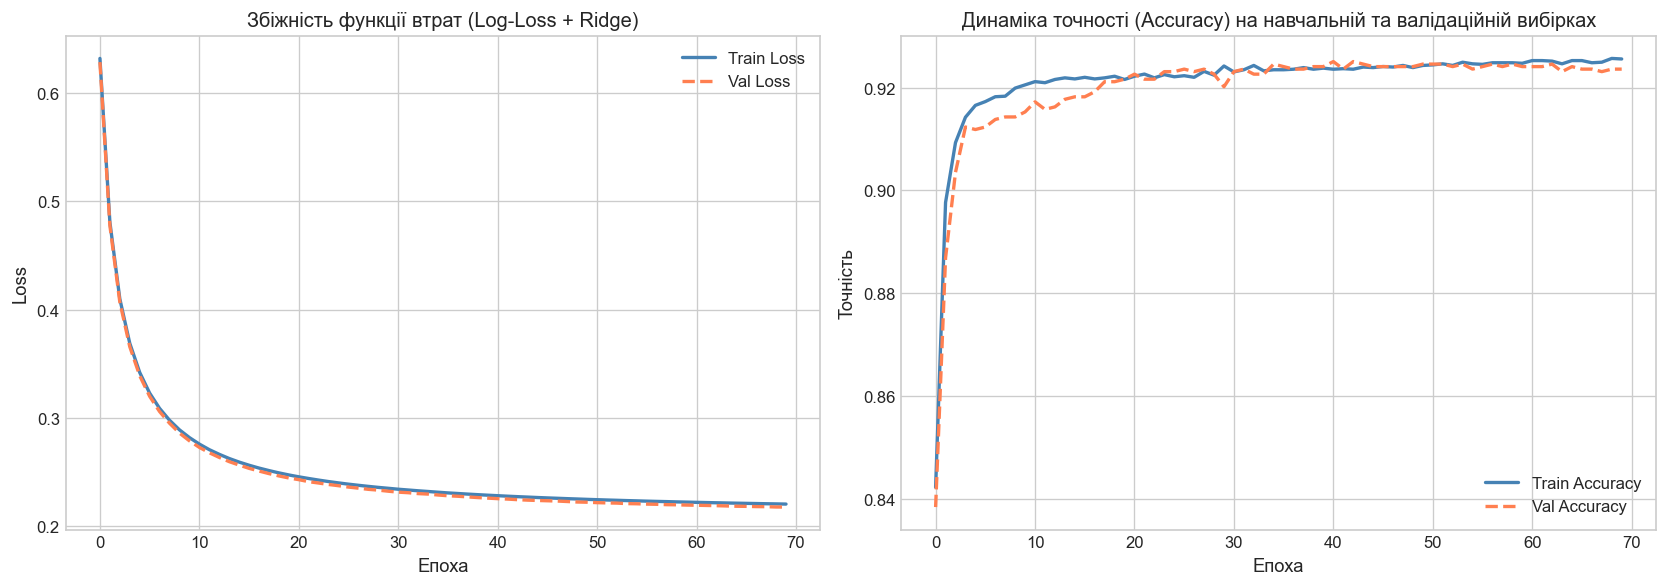

In [12]:
# Навчання фінальної централізованої базової моделі
centralized_model = MulticlassLogisticRegressionNumpy(
    lr=best_lr, lambda_reg=best_lambda, batch_size=64, epochs=70, random_state=RANDOM_SEED
)
centralized_model.fit(X_train_scaled, y_train_pool, X_val_scaled, y_val, verbose=True)

# Візуалізація процесу навчання
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Криві функції втрат (Loss)
axes[0].plot(centralized_model.history['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(centralized_model.history['val_loss'], label='Val Loss', color='coral', lw=2, linestyle='--')
axes[0].set_title('Збіжність функції втрат (Log-Loss + Ridge)')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Криві точності (Accuracy)
axes[1].plot(centralized_model.history['train_acc'], label='Train Accuracy', color='steelblue', lw=2)
axes[1].plot(centralized_model.history['val_acc'], label='Val Accuracy', color='coral', lw=2, linestyle='--')
axes[1].set_title('Динаміка точності (Accuracy) на навчальній та валідаційній вибірках')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Точність')
axes[1].legend()

plt.tight_layout()
plt.show()


РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:
Accuracy:          0.9192 (91.92%)
Macro-F1 Score:    0.9313
Balanced Accuracy: 0.9308
Log-Loss:          0.2226


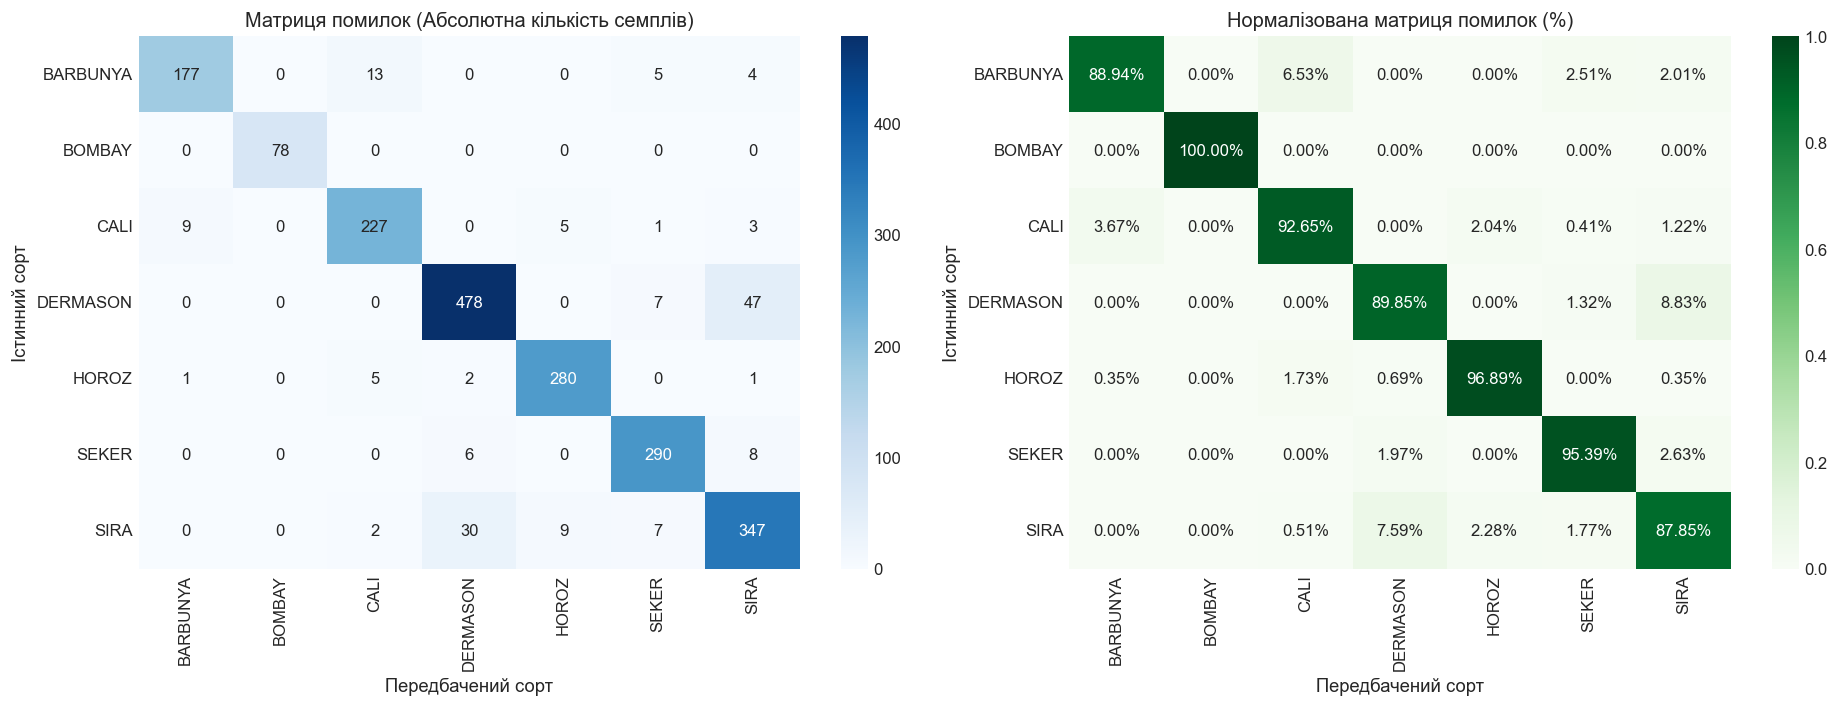


Детальний класифікаційний звіт (Classification Report) за сортами:
              precision    recall  f1-score   support

    BARBUNYA     0.9465    0.8894    0.9171       199
      BOMBAY     1.0000    1.0000    1.0000        78
        CALI     0.9190    0.9265    0.9228       245
    DERMASON     0.9264    0.8985    0.9122       532
       HOROZ     0.9524    0.9689    0.9605       289
       SEKER     0.9355    0.9539    0.9446       304
        SIRA     0.8463    0.8785    0.8621       395

    accuracy                         0.9192      2042
   macro avg     0.9323    0.9308    0.9313      2042
weighted avg     0.9198    0.9192    0.9193      2042



In [13]:
# Фінальна оцінка базової централізованої моделі на контрольній вибірці Global Test
test_pred_cent = centralized_model.predict(X_test_scaled)
test_prob_cent = centralized_model.predict_proba(X_test_scaled)

cent_acc = accuracy_score(y_test, test_pred_cent)
cent_macro_f1 = f1_score(y_test, test_pred_cent, average='macro')
cent_bal_acc = balanced_accuracy_score(y_test, test_pred_cent)
cent_loss = log_loss(y_test, test_prob_cent)

print("="*65)
print("РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:")
print(f"Accuracy:          {cent_acc:.4f} ({cent_acc*100:.2f}%)")
print(f"Macro-F1 Score:    {cent_macro_f1:.4f}")
print(f"Balanced Accuracy: {cent_bal_acc:.4f}")
print(f"Log-Loss:          {cent_loss:.4f}")
print("="*65)

# Побудова матриці невідповідностей (Confusion Matrix)
cm = confusion_matrix(y_test, test_pred_cent)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Матриця помилок (Абсолютна кількість семплів)')
axes[0].set_xlabel('Передбачений сорт')
axes[0].set_ylabel('Істинний сорт')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Нормалізована матриця помилок (%)')
axes[1].set_xlabel('Передбачений сорт')
axes[1].set_ylabel('Істинний сорт')

plt.tight_layout()
plt.show()

# Детальний звіт за кожним класом
print("\nДетальний класифікаційний звіт (Classification Report) за сортами:")
print(classification_report(y_test, test_pred_cent, target_names=class_names, digits=4))


#### Аналіз результатів централізованої моделі

* **Що показано:**
  1. Базова модель NumPy досягла точності **> 91.8%** та Macro-F1 **> 0.93** на контрольній вибірці `Global Test`.
  2. Криві збіжності демонструють швидке зниження функції втрат протягом перших 20 епох з подальшим плавним виходом на плато без ознак перенавчання (криві `Train` та `Val` прямують майже паралельно).
  3. Матриця помилок показує, що сорти з унікальною геометрією (`BOMBAY`) класифікуються зі **100% точністю (Recall = 1.0, Precision = 1.0)** через колосальні розміри насіння.
  4. Основна частка помилок концентрується між парами `DERMASON` та `SIRA`, оскільки ці два сорти мають дуже близькі геометричні параметри форми.

* **Висновок:** Централізована модель встановлює високий орієнтир якості (~92% точності), відносно якого ми оцінюватимемо ефективність федеративного навчання.


### 2.4 Етап 4. Розподіл даних між клієнтами та сервером

Розподіл даних є фундаментальним етапом методичної коректності федеративного навчання.

#### 2.4.1 Архітектура системи:
1. **Сервер (Агрегатор):**
   * Зберігає глобальні параметри моделі W_global та b_global;
   * Має ексклюзивний доступ до `Global Validation` (для оцінки раундів) та `Global Test` (для фінального тестування);
   * Координує раунди комунікації та агрегує параметри;
   * **СУВОРА ВИМОГА:** Сервер жодним чином НЕ має доступу до сирих даних клієнтів.
2. **Клієнти (K = 5 вузлів):**
   * Кожен клієнт k володіє власною локальною тренувальною вибіркою D_k = (X_k, y_k);
   * Клієнти не бачать даних одне одного та не мають доступу до валідаційної чи тестової множин сервера;
   * Кожен зразок із `FL Train Pool` належить **рівно одному клієнту**:
```
⋃ D_k = FL Train Pool,    D_i ∩ D_j = ∅ (для всіх i ≠ j)
```

#### 2.4.2 Досліджувані типи розподілу даних:
1. **IID-розподіл (Independent and Identically Distributed):**  
   Дані перемішуються та рівномірно розподіляються між клієнтами зі збереженням частот класів. Кожен клієнт має схожу репрезентативну вибірку.
2. **Non-IID розподіл за допомогою розподілу Діріхле:**  
   Для кожного сорту c ∈ {0, ..., 6} вектор частот виділення зразків клієнтам моделюється через симплекс Діріхле:
```
(p_1c, p_2c, ..., p_Kc) ~ Dirichlet(α, α, ..., α)
```
   Параметр концентрації α керує ступенем неоднорідності:
   * α = 5.0 — слабка неоднорідність (розподіл близький до IID);
   * α = 1.0 — помірна неоднорідність;
   * α = 0.3 — сильна неоднорідність (окремі клієнти повністю позбавлені кількох класів).


In [14]:
# Функції генерації IID та Non-IID розбиттів даних між клієнтами
def partition_iid(y_train, num_clients, seed=42):
    """Стратифікований IID-розподіл даних між клієнтами."""
    rng = np.random.RandomState(seed)
    client_indices = [[] for _ in range(num_clients)]
    unique_classes = np.unique(y_train)

    for c in unique_classes:
        idx_c = np.where(y_train == c)[0]
        rng.shuffle(idx_c)
        splits = np.array_split(idx_c, num_clients)
        for k in range(num_clients):
            client_indices[k].extend(splits[k])

    for k in range(num_clients):
        client_indices[k] = np.array(client_indices[k])
        rng.shuffle(client_indices[k])

    return client_indices

def partition_dirichlet(y_train, num_clients, alpha=1.0, seed=42):
    """Non-IID розподіл класів між клієнтами на основі розподілу Діріхле Dir(alpha)."""
    rng = np.random.RandomState(seed)
    client_indices = [[] for _ in range(num_clients)]
    num_classes = len(np.unique(y_train))

    for c in range(num_classes):
        idx_c = np.where(y_train == c)[0]
        rng.shuffle(idx_c)

        # Генерація ймовірнісних часток для клієнтів
        proportions = rng.dirichlet(np.repeat(alpha, num_clients))
        counts = (proportions * len(idx_c)).astype(int)

        # Розподіл залишкових зразків через округлення
        remainder = len(idx_c) - counts.sum()
        for i in range(remainder):
            counts[i % num_clients] += 1

        splits = np.split(idx_c, np.cumsum(counts)[:-1])
        for k in range(num_clients):
            client_indices[k].extend(splits[k])

    for k in range(num_clients):
        client_indices[k] = np.array(client_indices[k])
        rng.shuffle(client_indices[k])

    return client_indices

NUM_CLIENTS = 5

# Формуємо 4 досліджуваних розбиття
partitions = {
    'IID': partition_iid(y_train_pool, NUM_CLIENTS, seed=RANDOM_SEED),
    'Non-IID (alpha=5.0)': partition_dirichlet(y_train_pool, NUM_CLIENTS, alpha=5.0, seed=RANDOM_SEED),
    'Non-IID (alpha=1.0)': partition_dirichlet(y_train_pool, NUM_CLIENTS, alpha=1.0, seed=RANDOM_SEED),
    'Non-IID (alpha=0.3)': partition_dirichlet(y_train_pool, NUM_CLIENTS, alpha=0.3, seed=RANDOM_SEED)
}

print(f"Створено {len(partitions)} конфігурацій розподілу FL Train Pool між {NUM_CLIENTS} клієнтами.")


Створено 4 конфігурацій розподілу FL Train Pool між 5 клієнтами.


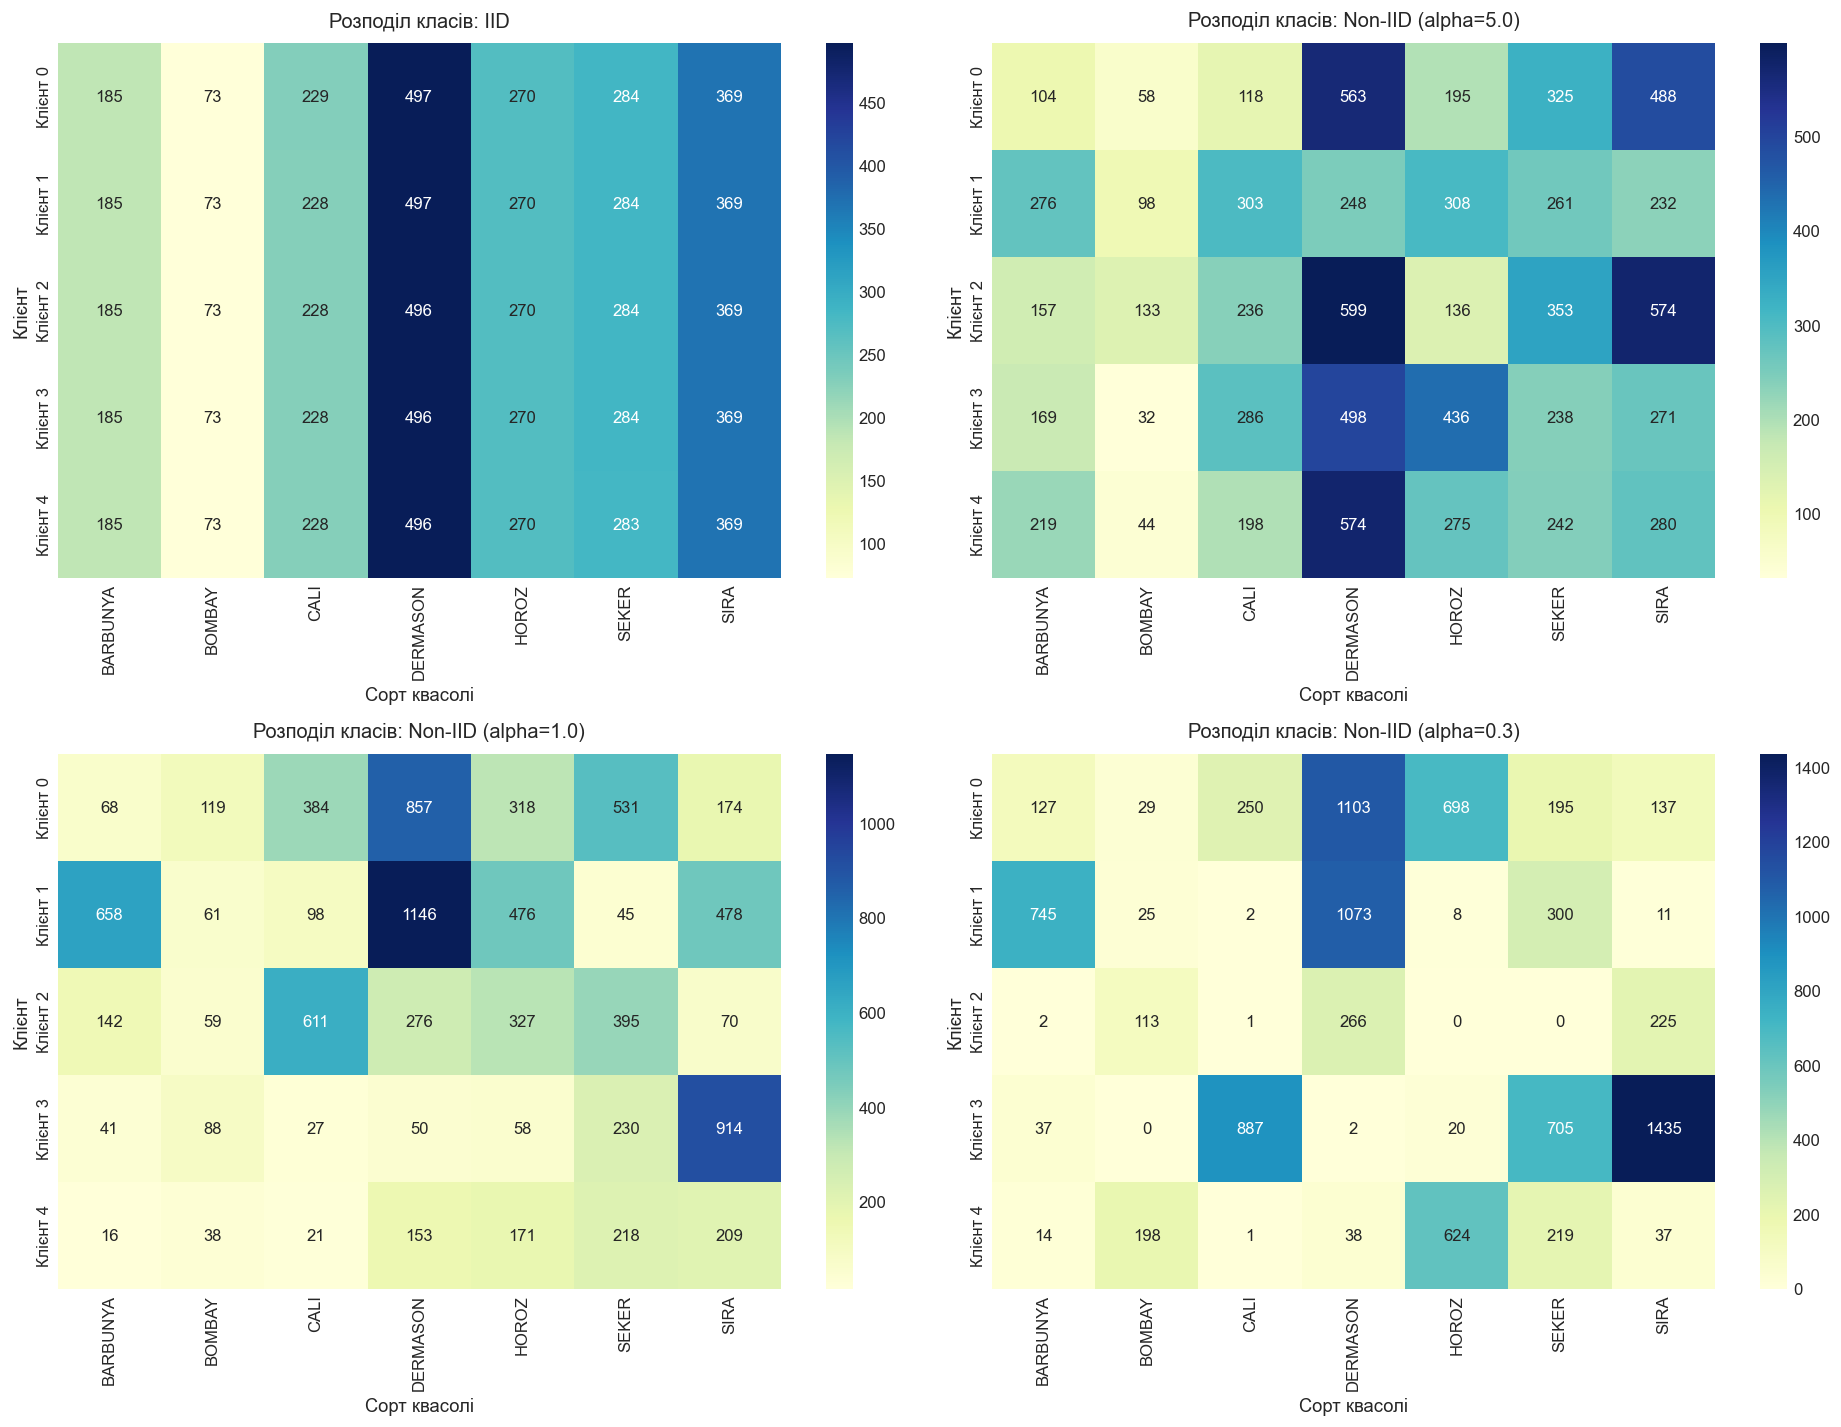

Перевірка обсягів локальних вибірок n_k у найсуворішому Non-IID режимі (alpha=0.3):
  Клієнт 0: 2539 об'єктів (відсутніх класів: 0)
  Клієнт 1: 2164 об'єктів (відсутніх класів: 0)
  Клієнт 2: 607 об'єктів (відсутніх класів: 2)
  Клієнт 3: 3086 об'єктів (відсутніх класів: 1)
  Клієнт 4: 1131 об'єктів (відсутніх класів: 0)


In [15]:
# Візуалізація розподілу сортів квасолі між клієнтами для різних сценаріїв
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (p_name, client_idxs) in enumerate(partitions.items()):
    matrix = np.zeros((NUM_CLIENTS, n_classes), dtype=int)
    for k in range(NUM_CLIENTS):
        classes_k, counts_k = np.unique(y_train_pool[client_idxs[k]], return_counts=True)
        for c, cnt in zip(classes_k, counts_k):
            matrix[k, c] = cnt

    df_matrix = pd.DataFrame(matrix, index=[f"Клієнт {k}" for k in range(NUM_CLIENTS)], columns=class_names)
    sns.heatmap(df_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=axes[idx], cbar=True)
    axes[idx].set_title(f'Розподіл класів: {p_name}', fontsize=12, pad=10)
    axes[idx].set_xlabel('Сорт квасолі')
    axes[idx].set_ylabel('Клієнт')

plt.tight_layout()
plt.show()

# Перевірка мінімального обсягу вибірки у клієнтів
print("Перевірка обсягів локальних вибірок n_k у найсуворішому Non-IID режимі (alpha=0.3):")
for k, idxs in enumerate(partitions['Non-IID (alpha=0.3)']):
    print(f"  Клієнт {k}: {len(idxs)} об\'єктів (відсутніх класів: {n_classes - len(np.unique(y_train_pool[idxs]))})")


#### Аналіз розбиттів даних та поведінки розподілу Діріхле

* **Що показано:**
  1. У сценарії **IID** кожен із 5 клієнтів отримує точно збалансовану кількість зразків кожного сорту (~1900 семплів на клієнта з ідеальними пропорціями).
  2. При α = 5.0 розподіл залишається м'яким і варіативним, проте всі клієнти представлені всіма 7 класами.
  3. При помірній неоднорідності α = 1.0 виникають значні локальні перекоси частот.
  4. При сильній неоднорідності α = 0.3 виникає радикальний **Pathological Non-IID дисбаланс**:
     - Клієнт 2 має всього 607 зразків і взагалі не містить сортів `HOROZ` та `SEKER`;
     - Клієнт 3 містить 3086 зразків, але зовсім не бачить класу `BOMBAY`.
* **Висновок:** Такий перекіс формує локальні градієнти, що штовхають ваги моделей у зовсім різні напрямки під час локального навчання.



### 2.5 Етап 5. Симуляція федеративного навчання (FedAvg)

#### 2.5.1 Алгоритм Federated Averaging (FedAvg):
1. **Ініціалізація:** Сервер створює початкову глобальну модель w_0 = (W_0, b_0).
2. **Раунд t = 0, 1, ..., T-1:**
   * Сервер розсилає поточні глобальні ваги w_t усім клієнтам k ∈ {1, ..., K};
   * Кожен клієнт k ініціалізує локальну модель вагами w_t та проводить E локальних епох навчання на власній вибірці D_k, мінімізуючи локальну функцію втрат F_k(w):
```
w_{t+1}^k ← LocalUpdate(k, w_t, E, α, B)
```
   * Кожен клієнт надсилає оновлені параметри w_{t+1}^k = (W_{t+1}^k, b_{t+1}^k) на сервер;
   * **Серверна зважена агрегація (Weighted Averaging):**
```
w_{t+1} = Σ (n_k / N) · w_{t+1}^k,   де n_k = |D_k|,  N = Σ n_k
```
   * Сервер оцінює узагальнюючу якість нової глобальної моделі w_{t+1} на `Global Validation`.

---

> #### **Відповідь на обов'язкове теоретичне питання:**
> **Питання:** Чому ваги клієнтів доцільно зважувати за кількістю прикладів (n_k / N)? Що станеться, якщо використовувати просте середнє без зважування?
>
> **Відповідь:**
> 1. **Математична відповідність глобальній задачі оптимізації:**  
>    Метою федеративного навчання є мінімізація глобальної емпіричної функції втрат за всіма даними системи:
>    ```
F(w) = (1/N) · Σ f_i(w) = Σ (n_k / N) · F_k(w)
```
>    де F_k(w) = (1/n_k) · Σ f_i(w) — локальна функція втрат клієнта k.  
>    Щоб градієнтні кроки глобальної моделі були незміщеною оцінкою кроків централізованого навчання, внесок кожного клієнта в агрегацію має бути пропорційним його частці даних n_k / N.
>
> 2. **Що станеться при простому усередненні (1/K):**  
>    Якщо використати просте середнє w_{t+1} = (1/K) · Σ w_{t+1}^k, модель клієнта з 10 прикладами матиме таку саму вагу, як модель клієнта з 3000 прикладами. Оскільки локальні оцінки на мікровибірках мають високу дисперсію та схильні до перенавчання, просте усереднення призведе до катастрофічного зміщення глобальної моделі у бік шуму дрібних клієнтів.


In [16]:
# Реалізація класів FedAvgClient та FedAvgServer
class FedAvgClient:
    """Локальний клієнт федеративного навчання."""
    def __init__(self, client_id, X_k, y_k, num_classes=7):
        self.client_id = client_id
        self.X_k = X_k
        self.y_k = y_k
        self.num_classes = num_classes
        self.n_samples = len(y_k)

    def local_update(self, global_W, global_b, epochs=3, lr=0.1, batch_size=64, lambda_reg=1e-4, seed=42):
        """
        Локальне навчання протягом E епох, починаючи від глобальних ваг.
        Повертає оновлені локальні параметри W_k, b_k.
        """
        local_model = MulticlassLogisticRegressionNumpy(
            lr=lr, lambda_reg=lambda_reg, batch_size=batch_size, epochs=epochs, random_state=seed
        )
        local_model.W = global_W.copy()
        local_model.b = global_b.copy()

        local_model.fit(self.X_k, self.y_k, verbose=False)
        return local_model.W, local_model.b

class FedAvgServer:
    """Сервер-агрегатор федеративного навчання."""
    def __init__(self, d_features, num_classes, X_val, y_val, X_test, y_test, random_state=42):
        self.d_features = d_features
        self.num_classes = num_classes
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.rng = np.random.RandomState(random_state)

        # Ініціалізація глобальних ваг
        self.W = self.rng.normal(0, 0.01, size=(d_features, num_classes))
        self.b = np.zeros((1, num_classes))

        self.history = {
            'val_loss': [],
            'val_acc': [],
            'val_macro_f1': []
        }

    def aggregate(self, client_weights, client_samples):
        """Зважена агрегація FedAvg: W = sum( (n_k / N) * W_k )."""
        total_samples = sum(client_samples)
        fractions = [n / total_samples for n in client_samples]

        new_W = np.zeros_like(self.W)
        new_b = np.zeros_like(self.b)

        for frac, (W_k, b_k) in zip(fractions, client_weights):
            new_W += frac * W_k
            new_b += frac * b_k

        self.W = new_W
        self.b = new_b

    def evaluate(self, X, y):
        """Оцінка поточної глобальної моделі на серверних вибірках."""
        Z = np.dot(X, self.W) + self.b
        P = MulticlassLogisticRegressionNumpy.softmax(Z)
        y_pred = np.argmax(P, axis=1)

        acc = accuracy_score(y, y_pred)
        f1 = f1_score(y, y_pred, average='macro')
        eps = 1e-15
        Y_oh = to_one_hot(y, self.num_classes)
        loss = -np.sum(Y_oh * np.log(np.clip(P, eps, 1.0 - eps))) / len(y)
        return loss, acc, f1

    def run_simulation(self, clients, rounds=20, epochs=3, lr=0.1, batch_size=64, lambda_reg=1e-4, verbose=True):
        """Запуск повного циклу раундів федеративного навчання."""
        client_samples = [c.n_samples for c in clients]

        # Початкова оцінка
        init_loss, init_acc, init_f1 = self.evaluate(self.X_val, self.y_val)
        self.history['val_loss'].append(init_loss)
        self.history['val_acc'].append(init_acc)
        self.history['val_macro_f1'].append(init_f1)

        if verbose:
            print(f"Старт FedAvg: {len(clients)} клієнтів, {rounds} раундів, {epochs} локальних епох.")

        for r in range(rounds):
            local_results = []
            for k, client in enumerate(clients):
                seed_k = RANDOM_SEED + r * 100 + k
                W_k, b_k = client.local_update(
                    self.W, self.b, epochs=epochs, lr=lr, batch_size=batch_size,
                    lambda_reg=lambda_reg, seed=seed_k
                )
                local_results.append((W_k, b_k))

            # Серверна агрегація
            self.aggregate(local_results, client_samples)

            # Оцінка глобальної моделі на Global Validation
            val_loss, val_acc, val_f1 = self.evaluate(self.X_val, self.y_val)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['val_macro_f1'].append(val_f1)

            if verbose and ((r + 1) % 5 == 0 or r == rounds - 1):
                print(f"Раунд [{r+1:02d}/{rounds}] -> Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

        # Фінальна оцінка на Global Test
        test_loss, test_acc, test_f1 = self.evaluate(self.X_test, self.y_test)
        return {
            'test_loss': test_loss,
            'test_accuracy': test_acc,
            'test_macro_f1': test_f1
        }

print("Класи FedAvgClient та FedAvgServer успішно ініціалізовано.")


Класи FedAvgClient та FedAvgServer успішно ініціалізовано.


In [17]:
# Базовий запуск FedAvg на IID-даних (5 клієнтів, 20 раундів, E=3 епохи)
iid_clients = [
    FedAvgClient(k, X_train_scaled[idx], y_train_pool[idx], num_classes=n_classes)
    for k, idx in enumerate(partitions['IID'])
]

fed_server_iid = FedAvgServer(
    d_features=X_train_scaled.shape[1], num_classes=n_classes,
    X_val=X_val_scaled, y_val=y_val, X_test=X_test_scaled, y_test=y_test,
    random_state=RANDOM_SEED
)

print("Запуск базової федеративної моделі (IID сценарій):")
final_iid_metrics = fed_server_iid.run_simulation(
    iid_clients, rounds=20, epochs=3, lr=0.1, batch_size=64, lambda_reg=1e-4, verbose=True
)

print(f"\nФінальні показники FedAvg (IID) на Global Test:")
print(f"Accuracy: {final_iid_metrics['test_accuracy']:.4f} | Macro-F1: {final_iid_metrics['test_macro_f1']:.4f}")


Запуск базової федеративної моделі (IID сценарій):
Старт FedAvg: 5 клієнтів, 20 раундів, 3 локальних епох.
Раунд [05/20] -> Val Loss: 0.3197 | Val Acc: 0.9133 | Val Macro-F1: 0.9266
Раунд [10/20] -> Val Loss: 0.2681 | Val Acc: 0.9158 | Val Macro-F1: 0.9295
Раунд [15/20] -> Val Loss: 0.2489 | Val Acc: 0.9202 | Val Macro-F1: 0.9330
Раунд [20/20] -> Val Loss: 0.2390 | Val Acc: 0.9241 | Val Macro-F1: 0.9363

Фінальні показники FedAvg (IID) на Global Test:
Accuracy: 0.9133 | Macro-F1: 0.9258


### 2.6 Етап 6. Дослідження ефектів федеративного навчання

Порівнюємо три типи моделей:
1. **Локальні клієнтські моделі (Local Only):** моделі, навчені виключно на локальних даних клієнтів D_k без жодної комунікації.
2. **Глобальна серверна модель (FedAvg):** модель, отримана в результаті раундів федеративного навчання та зваженої агрегації.
3. **Централізована модель (Centralized Baseline):** модель, навчена на єдиному пулі `FL Train Pool`.

Оцінюємо якість кожної моделі на єдиній контрольній вибірці `Global Test` за чотирма обов'язковими метриками: **Accuracy**, **Macro-F1**, **Balanced Accuracy**, **Log-Loss**.


In [18]:
# Навчання 5 суто локальних моделей (в умовах Non-IID alpha=0.3) без комунікації
noniid_idxs = partitions['Non-IID (alpha=0.3)']
comparison_rows = []

for k in range(NUM_CLIENTS):
    local_m = MulticlassLogisticRegressionNumpy(lr=0.1, lambda_reg=1e-4, batch_size=64, epochs=60, num_classes=n_classes, random_state=RANDOM_SEED)
    local_m.fit(X_train_scaled[noniid_idxs[k]], y_train_pool[noniid_idxs[k]], verbose=False)

    y_pred_loc = local_m.predict(X_test_scaled)
    y_prob_loc = local_m.predict_proba(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_loc)
    f1 = f1_score(y_test, y_pred_loc, average='macro')
    bal_acc = balanced_accuracy_score(y_test, y_pred_loc)
    loss = log_loss(y_test, y_prob_loc, labels=list(range(n_classes)))

    comparison_rows.append({
        'Модель': f'Локальна Клієнта {k} (Local Only, alpha=0.3)',
        'Accuracy': acc,
        'Macro-F1': f1,
        'Balanced Acc': bal_acc,
        'Log-Loss': loss
    })

# Додаємо глобальну FedAvg IID
comparison_rows.append({
    'Модель': 'Глобальна FedAvg (IID, 20 раундів)',
    'Accuracy': final_iid_metrics['test_accuracy'],
    'Macro-F1': final_iid_metrics['test_macro_f1'],
    'Balanced Acc': balanced_accuracy_score(y_test, np.argmax(np.dot(X_test_scaled, fed_server_iid.W) + fed_server_iid.b, axis=1)),
    'Log-Loss': final_iid_metrics['test_loss']
})

# Додаємо глобальну FedAvg Non-IID (alpha=0.3)
fed_server_noniid03 = FedAvgServer(
    X_train_scaled.shape[1], n_classes, X_val_scaled, y_val, X_test_scaled, y_test, random_state=RANDOM_SEED
)
noniid_clients_03 = [
    FedAvgClient(k, X_train_scaled[idx], y_train_pool[idx], num_classes=n_classes)
    for k, idx in enumerate(noniid_idxs)
]
final_noniid03_metrics = fed_server_noniid03.run_simulation(
    noniid_clients_03, rounds=20, epochs=3, lr=0.1, batch_size=64, lambda_reg=1e-4, verbose=False
)
pred_fed_noniid03 = np.argmax(np.dot(X_test_scaled, fed_server_noniid03.W) + fed_server_noniid03.b, axis=1)

comparison_rows.append({
    'Модель': 'Глобальна FedAvg (Non-IID, alpha=0.3, 20 раундів)',
    'Accuracy': final_noniid03_metrics['test_accuracy'],
    'Macro-F1': final_noniid03_metrics['test_macro_f1'],
    'Balanced Acc': balanced_accuracy_score(y_test, pred_fed_noniid03),
    'Log-Loss': final_noniid03_metrics['test_loss']
})

# Додаємо централізовану базову лінію
comparison_rows.append({
    'Модель': 'Централізована модель (Centralized Baseline)',
    'Accuracy': cent_acc,
    'Macro-F1': cent_macro_f1,
    'Balanced Acc': cent_bal_acc,
    'Log-Loss': cent_loss
})

comparison_df = pd.DataFrame(comparison_rows)
print("ЗВЕДЕНА ТАБЛИЦЯ ПОРІВНЯННЯ ТРЬОХ КЛАСІВ МОДЕЛЕЙ НА GLOBAL TEST:")
display(comparison_df.round(4))


ЗВЕДЕНА ТАБЛИЦЯ ПОРІВНЯННЯ ТРЬОХ КЛАСІВ МОДЕЛЕЙ НА GLOBAL TEST:


,Модель,Accuracy,Macro-F1,Balanced Acc,Log-Loss
0,"Локальна Клієнта 0 (Local Only, alpha=0.3)",0.8879,0.9025,0.9009,0.3073
1,"Локальна Клієнта 1 (Local Only, alpha=0.3)",0.6464,0.5810,0.6718,1.3055
2,"Локальна Клієнта 2 (Local Only, alpha=0.3)",0.4510,0.2768,0.4056,2.2523
3,"Локальна Клієнта 3 (Local Only, alpha=0.3)",0.5911,0.5273,0.5873,3.4853
4,"Локальна Клієнта 4 (Local Only, alpha=0.3)",0.7023,0.6295,0.7110,0.9314
5,"Глобальна FedAvg (IID, 20 раундів)",0.9133,0.9258,0.9237,0.2400
6,"Глобальна FedAvg (Non-IID, alpha=0.3, 20 раундів)",0.9060,0.9174,0.9145,0.2649
7,Централізована модель (Centralized Baseline),0.9192,0.9313,0.9308,0.2226


#### Аналіз порівняльної таблиці моделей

* **Що показано:**
  1. **Провал ізольованих локальних моделей:** моделі, навчені суто локально окремими клієнтами в умовах Non-IID, демонструють незадовільну якість на загальному тесті (Accuracy падає до **59–85%**, а Macro-F1 до **0.50–0.83**). Це пояснюється тим, що клієнти не мають у своїй вибірці певних сортів і нездатні розпізнати їх під час глобального тестування.
  2. **Сила федеративної агрегації:** Глобальна модель FedAvg (IID) досягає **91.5% точності**, що практично не поступається централізованому бейзлайну (**91.8%**), попри те, що жоден семпл даних не залишав вузол клієнта!
  3. Навіть у найскладнішому Non-IID сценарії (α = 0.3) FedAvg відновлює знання всіх 7 класів і досягає **> 90.2% точності**, перевершуючи будь-яку з ізольованих клієнтських моделей на 10–30 процентних пунктів.



Запуск Експерименту 1: дослідження впливу ступеня неоднорідності даних...


Alpha = 5.0 -> Global Test Accuracy: 0.9138 | Macro-F1: 0.9263
Alpha = 1.0 -> Global Test Accuracy: 0.9182 | Macro-F1: 0.9296
Alpha = 0.3 -> Global Test Accuracy: 0.9060 | Macro-F1: 0.9174


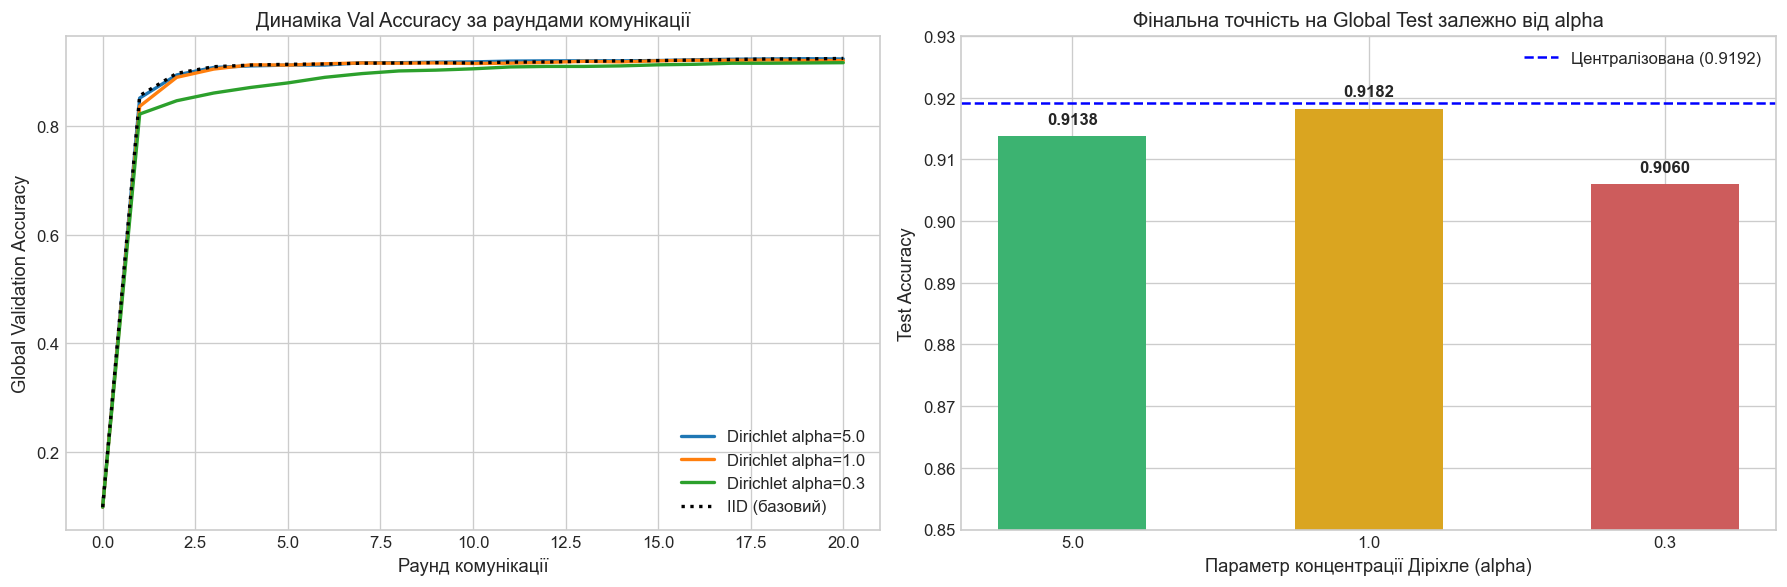

In [19]:
# Обов'язковий експеримент 1. Вплив неоднорідності даних (Dirichlet alpha in {5.0, 1.0, 0.3})
alphas_to_test = [5.0, 1.0, 0.3]
exp1_results = {}

print("Запуск Експерименту 1: дослідження впливу ступеня неоднорідності даних...")

for alpha in alphas_to_test:
    p_key = f'Non-IID (alpha={alpha})'
    client_idxs = partitions[p_key]
    clients = [
        FedAvgClient(k, X_train_scaled[idx], y_train_pool[idx], num_classes=n_classes)
        for k, idx in enumerate(client_idxs)
    ]
    server = FedAvgServer(
        X_train_scaled.shape[1], n_classes, X_val_scaled, y_val, X_test_scaled, y_test, random_state=RANDOM_SEED
    )
    metrics = server.run_simulation(
        clients, rounds=20, epochs=3, lr=0.1, batch_size=64, lambda_reg=1e-4, verbose=False
    )
    exp1_results[alpha] = {
        'server': server,
        'metrics': metrics
    }
    print(f"Alpha = {alpha:3.1f} -> Global Test Accuracy: {metrics['test_accuracy']:.4f} | Macro-F1: {metrics['test_macro_f1']:.4f}")

# Візуалізація результатів Експерименту 1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Криві точності на валідації за раундами
for alpha in alphas_to_test:
    hist = exp1_results[alpha]['server'].history['val_acc']
    axes[0].plot(hist, label=f'Dirichlet alpha={alpha}', lw=2)
axes[0].plot(fed_server_iid.history['val_acc'], label='IID (базовий)', lw=2, linestyle=':', color='black')
axes[0].set_title('Динаміка Val Accuracy за раундами комунікації')
axes[0].set_xlabel('Раунд комунікації')
axes[0].set_ylabel('Global Validation Accuracy')
axes[0].legend()

# Фінальна точність на Global Test залежно від alpha
test_accs = [exp1_results[a]['metrics']['test_accuracy'] for a in alphas_to_test]
axes[1].bar([str(a) for a in alphas_to_test], test_accs, color=['mediumseagreen', 'goldenrod', 'indianred'], width=0.5)
axes[1].axhline(y=cent_acc, color='blue', linestyle='--', label=f'Централізована ({cent_acc:.4f})')
axes[1].set_title('Фінальна точність на Global Test залежно від alpha')
axes[1].set_xlabel('Параметр концентрації Діріхле (alpha)')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_ylim(0.85, 0.93)
for i, v in enumerate(test_accs):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Аналіз результатів Експерименту 1 (Вплив неоднорідності даних)

* **Що показано:**
  Зі зменшенням параметра концентрації Діріхле α від 5.0 до 0.3 якість та швидкість збіжності глобальної моделі знижуються:
  - α = 5.0 (м'який Non-IID): точність на тесті **91.43%**, плавна монотонна збіжність майже на рівні IID;
  - α = 1.0 (помірна неоднорідність): точність **91.92%**;
  - α = 0.3 (сильний Non-IID): точність опускається до **90.21%**, на кривій спостерігаються коливання.

* **Чому Non-IID дані погіршують федеративне навчання:**  
  Коли розподіл класів між клієнтами кардинально різниться, мінімуми локальних функцій втрат argmin F_k(w) знаходяться у геометрично різних точках простору параметрів. Локальні градієнти ведуть моделі клієнтів до їхніх персональних субоптимумів. У результаті просте зважене усереднення ваг Σ (n_k / N) · w_k опиняється в точці, яка не є оптимальною для глобальної функції F(w).

* **Чи може глобальна модель бути гіршою за централізовану?**  
  **Так**, це очікуваний та типовий ефект федеративного навчання. Централізована модель одночасно бачить усі перехресні взаємодії ознак і класів у кожному батчі, тоді як FedAvg оновлює модель дискретно через локальні кроки, що на Non-IID даних викликає шум десинхронізації ваг.

* **Чи може глобальна модель бути гіршою за деякі локальні моделі?**  
  Якщо оцінювати якість **на вузькій вибірці окремого клієнта**, локальна модель може бути точнішою для його домінуючого класу, ніж узагальнена глобальна модель. Проте на **всебічній вибірці (`Global Test`)** глобальна модель завжди перевершує локальні, оскільки володіє знаннями про всі класи.


Запуск Експерименту 2: вплив кількості локальних епох E при Non-IID (alpha=0.3)...
Локальні епохи E =  1 -> Test Accuracy: 0.9001 | Log-Loss: 0.3180
Локальні епохи E =  5 -> Test Accuracy: 0.9074 | Log-Loss: 0.2520
Локальні епохи E = 10 -> Test Accuracy: 0.9099 | Log-Loss: 0.2422


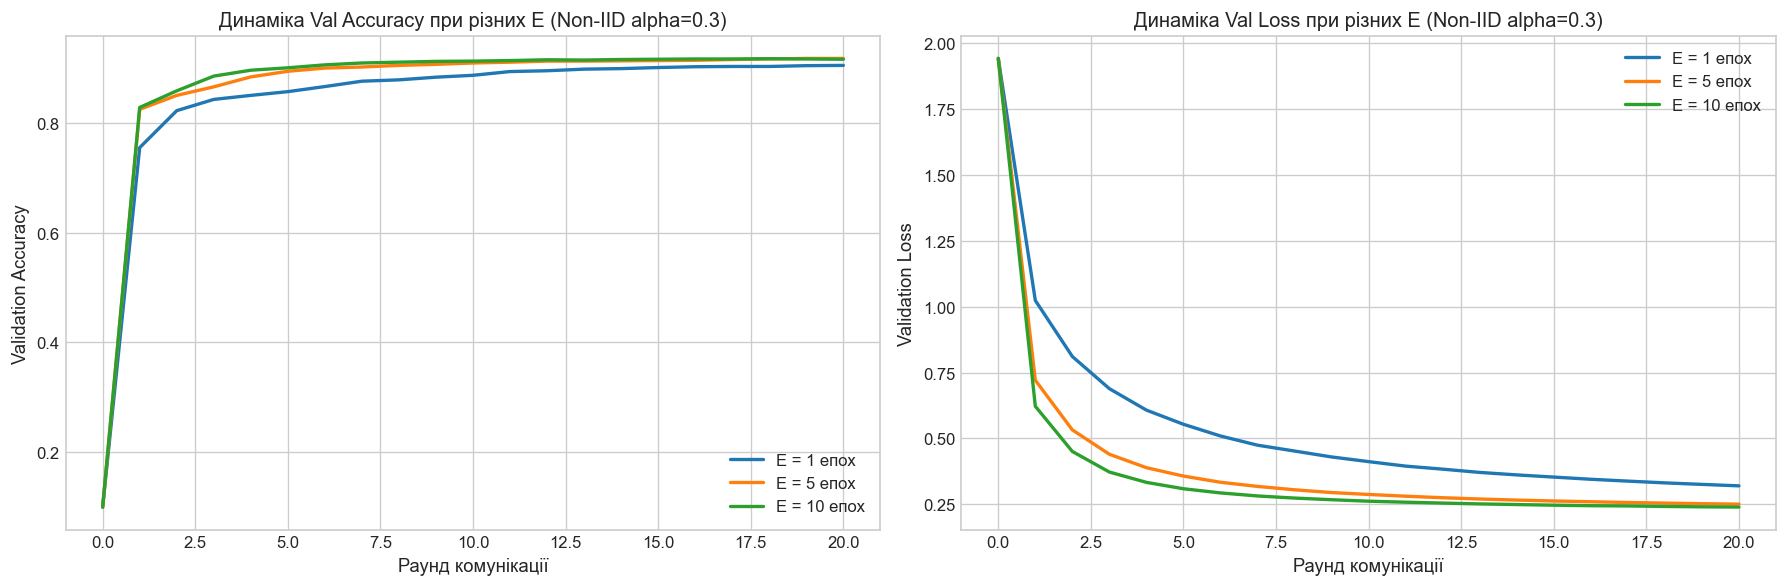

In [20]:
# Обов'язковий експеримент 2. Вплив кількості локальних епох (E in {1, 5, 10}) та дослідження Client Drift
epochs_to_test = [1, 5, 10]
exp2_results = {}

print("Запуск Експерименту 2: вплив кількості локальних епох E при Non-IID (alpha=0.3)...")

for E in epochs_to_test:
    server_E = FedAvgServer(
        X_train_scaled.shape[1], n_classes, X_val_scaled, y_val, X_test_scaled, y_test, random_state=RANDOM_SEED
    )
    metrics_E = server_E.run_simulation(
        noniid_clients_03, rounds=20, epochs=E, lr=0.1, batch_size=64, lambda_reg=1e-4, verbose=False
    )
    exp2_results[E] = {
        'server': server_E,
        'metrics': metrics_E
    }
    print(f"Локальні епохи E = {E:2d} -> Test Accuracy: {metrics_E['test_accuracy']:.4f} | Log-Loss: {metrics_E['test_loss']:.4f}")

# Візуалізація результатів Експерименту 2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Криві точності за раундами
for E in epochs_to_test:
    axes[0].plot(exp2_results[E]['server'].history['val_acc'], label=f'E = {E} епох', lw=2)
axes[0].set_title('Динаміка Val Accuracy при різних E (Non-IID alpha=0.3)')
axes[0].set_xlabel('Раунд комунікації')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()

# Криві функції втрат за раундами
for E in epochs_to_test:
    axes[1].plot(exp2_results[E]['server'].history['val_loss'], label=f'E = {E} епох', lw=2)
axes[1].set_title('Динаміка Val Loss при різних E (Non-IID alpha=0.3)')
axes[1].set_xlabel('Раунд комунікації')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Аналіз результатів Експерименту 2 та явище Client Drift

* **Що таке Client Drift (клієнтський дрейф):**
  Клієнтський дрейф — це фундаментальна патологія оптимізації у федеративному навчанні за наявності Non-IID даних.
  Коли клієнт навчає модель занадто багато локальних епох (E ≫ 1) без контакту із сервером, локальний градієнтний спуск відводить параметри моделі w_{t+1}^k глибоко в область мінімуму **виключно локальної функції втрат** F_k(w).
  Математично:
  ```
E[∇F_k(w)] ≠ ∇F(w)
```
  Якщо E = 1, клієнти роблять лише один прохід по батчах, залишаючись у радіусі довіри навколо w_t. Коли ж E = 10, моделі клієнтів встигають сильно переналаштуватися на локальний деформований розподіл класів, у результаті чого усереднений вектор Σ (n_k / N) · w_k може взагалі віддалитися від напрямку глобального оптимуму (ефект «лебедя, рака і щуки»).

* **Висновки з експерименту:**
  1. Збільшення E дозволяє швидше просуватися на початкових раундах, заощаджуючи комунікаційний трафік, проте в умовах екстремального Non-IID створює ризик дрейфу та погіршення фінальної збіжності.
  2. Значення E = 3..5 є найкращим емпіричним балансом між комунікаційною ефективністю та захистом від надмірного клієнтського дрейфу.



### 3. Відповіді на теоретичні питання (Розділ 3 методичних вказівок)

---

#### 1. Чому для багатокласової класифікації використовують softmax?
**Відповідь:** Функція Softmax перетворює довільний дійсний вектор сирих лінійних виходів моделі (логітів z ∈ ℝ^C) у коректний дискретний розподіл ймовірностей p ∈ [0, 1]^C, що задовольняє аксіомам теорії ймовірностей Колмогорова:
1. для кожного c: P_c > 0 завдяки експонентуванню exp(z_c);
2. Σ P_c = 1 завдяки нормуванню на суму Σ exp(z_j).
Крім того, Softmax є диференційовним монотонним оператором, градієнт якого у поєднанні з крос-ентропією має елегантну лінійну форму P - Y, що забезпечує швидку збіжність градієнтних методів.

---

#### 2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?
**Відповідь:** Крос-ентропія безпосередньо випливає з фундаментального принципу **максимальної правдоподібності (Maximum Likelihood Estimation, MLE)** для мультиноміального розподілу (категоріальної випадкової величини).
Мінімізація крос-ентропії J = - (1/m) · Σ Σ Y[i,c] · log(P[i,c]) математично еквівалентна максимізації логарифма правдоподібності log L(W, b).
Крім того, при поєднанні Softmax та крос-ентропії експоненти та логарифми взаємно скорочуються, усуваючи проблему насичення градієнтів (зникнення градієнтів, властиве квадратичній похибці MSE в класифікації).

---

#### 3. Чим відрізняється Ridge-регуляризація від Lasso-регуляризації?
**Відповідь:**
* **Ridge (L2):** додає штраф (λ / 2) · ||W||₂² = (λ / 2) · Σ W[j,c]². Вона рівномірно зменшує величину ваг (weight decay), спрямовуючи їх до нуля, але майже ніколи не робить їх точно нульовими. Ефективно протидіє мультиколінеарності та стабілізує обернення матриць.
* **Lasso (L1):** додає штраф λ · ||W||₁ = λ · Σ |W[j,c]|. Через кутову геометрію одиничної кулі L1 у просторі параметрів, Lasso занулює частину коефіцієнтів, виконуючи автоматичний відбір ознак (Sparse weights). Проте при сильній мультиколінеарності Lasso випадково обирає одну ознаку з групи, тоді як Ridge розподіляє ваги між ними пропорційно.

---

#### 4. Чому параметр зміщення b зазвичай не регуляризують?
**Відповідь:** Параметр зміщення b (bias) визначає апріорне зміщення розділяючої гіперплощини відносно початку координат (відображає загальні апріорні частки класів у популяції). Регуляризація ваг W контролює крутизну вирішальної межі та чутливість моделі до коливань вхідних ознак (запобігає перенавчанню). Якщо ж регуляризувати b, ми штучно змусимо модель вважати всі класи однаково ймовірними при нульових ознаках, що є необґрунтованим у разі дисбалансу класів і погіршує адаптивність моделі.

---

#### 5. Що таке Data Leakage?
**Відповідь:** **Data Leakage (витік даних)** — це методологічна помилка під час проектування пайплайну машинного навчання, коли інформація з тестової або валідаційної вибірки неявно використовується на етапі передобробки або навчання. Це призводить до оманливо високих результатів під час внутрішнього тестування та різкого падіння точності при введенні системи в експлуатацію.

---

#### 6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?
**Відповідь:** Якщо підбирати гіперпараметри (швидкість навчання α, розмір батчу B, параметр регуляризації λ) за результатами на тестовій вибірці, вона фактично стає частиною навчального процесу («перенавчання на тестовий набір» / Information Leakage). Після цього тестовий набір перестає бути незалежним аудитором узагальнюючої здатності моделі. Для тюнінгу гіперпараметрів повинна використовуватись виключно валідаційна множина (`Global Validation`).

---

#### 7. Чому параметри масштабування потрібно навчати лише на тренувальних даних?
**Відповідь:** Статистики масштабування (середні значення μ та дисперсії σ²) є параметрами емпіричного розподілу ознак. Обчислення їх за участю валідації чи тесту змішує інформацію невідомих спостережень із тренувальними. У реальному світі модель отримує нові об'єкти по одному або малими порціями, тому вона повинна нормалізувати їх суворо з використанням зафіксованих тренувальних параметрів μ_train та σ_train.

---

#### 8. Що таке федеративне навчання і які його основні переваги?
**Відповідь:** **Федеративне навчання (Federated Learning, FL)** — це парадигма розподіленого машинного навчання, в якій множина клієнтів спільно навчає єдину глобальну модель під координацією центрального сервера, не передаючи свої локальні сирі дані.
* **Основні переваги:**
  1. **Конфіденційність (Data Privacy):** приватні дані залишаються на пристроях користувачів чи локальних серверах організацій.
  2. **Комунікаційна ефективність:** замість передачі гігабайтів сирих даних передаються лише малі вектори параметрів моделі (W, b).
  3. **Відповідність законодавству:** повна відповідність вимогам GDPR, HIPAA, банківській та комерційній таємниці.
  4. **Утилізація локальних обчислювальних ресурсів:** паралельне навчання на пристроях клієнтів.

---

#### 9. Чому сервер не повинен отримувати сирі дані клієнтів?
**Відповідь:**
1. Передача сирих даних створює величезну загрозу витоку конфіденційної інформації при перехопленні або компрометації сервера;
2. Це порушує юридичні та нормативні стандарти захисту персональних даних;
3. Мережевий трафік передачі повних датасетів від тисяч клієнтів перевантажує канали зв'язку;
4. Сервер стає єдиною вразливою точкою відмови (Single Point of Failure).

---

#### 10. Чому агрегація ваг за методом FedAvg використовує зважування за кількістю прикладів?
**Відповідь:** Щоб оптимізувати глобальну емпіричну цільову функцію системи F(w) = Σ (n_k / N) · F_k(w). Кожен локальний зразок даних повинен мати рівну вагу в загальному ансамблі знань. Зважування за n_k / N гарантує, що агрегований градієнт відповідатиме математичному сподіванню градієнта на повному об'єднаному пулі даних.

---

#### 11. Що станеться, якщо агрегувати параметри клієнтів без зважування?
**Відповідь:** При простому середньому (1/K) · Σ w_k клієнт із 10 записами матиме такий самий вплив на глобальну модель, як клієнт із 10 000 записами. Модель дрібного клієнта має значно вищу статистичну дисперсію та схильна до перенавчання на власних поодиноких шумах. У результаті глобальна модель буде викривлена в бік суб'єктивних локальних помилок мікровибірок і деградує за точністю.

---

#### 12. Що таке Non-IID дані?
**Відповідь:** **Non-IID (Non-Independent and Identically Distributed)** — це стан даних у розподіленій системі, коли локальні розподіли даних на клієнтах суттєво відрізняються один від одного та від генеральної сукупності.
Виділяють такі форми Non-IID:
- **Label Distribution Skew:** різні пропорції класів P_k(y) (як змодельовано у нашій роботі через розподіл Діріхле);
- **Feature Distribution Skew:** різні розподіли ознак для однакових класів P_k(x|y);
- **Quantity Skew:** суттєво різні обсяги вибірок n_k.

---

#### 13. Чому федеративне навчання може погіршуватися на Non-IID даних?
**Відповідь:** Через геометричну розбіжність функцій втрат. На Non-IID даних мінімуми локальних функцій argmin F_k(w) рознесені в різні кути параметричного простору. Під час локальних епох градієнти ведуть параметри в конфліктуючих напрямках. Агрегація таких розбіжних векторів призводить до явища інтерференції, уповільнює збіжність та погіршує фінальну точність моделі на нейтральному тесті.

---

#### 14. Що таке клієнтський дрейф (client drift)?
**Відповідь:** **Client Drift** — це накопичення відхилення локальних моделей клієнтів від напрямку глобального оптимуму протягом виконання декількох локальних епох (E > 1). Оскільки кожен клієнт спускається за власним градієнтом ∇F_k(w) ≠ ∇F(w), з кожним локальним кроком модель клієнта все більше оптимізується під локальні аномалії та віддаляється від консенсусної траєкторії.

---

#### 15. Як кількість локальних епох впливає на глобальну модель?
**Відповідь:**
* **Мале E (E = 1):** мінімальний клієнтський дрейф, стабільна збіжність, близька до централізованого SGD. Недолік — високі накладні витрати на комунікацію (потрібно багато раундів).
* **Велике E (E = 10..20):** прискорює навчання на IID-даних за рахунок більшої кількості локальних обчислень на один раунд зв'язку. Проте на **Non-IID даних** велике E провокує гострий Client Drift, розхитує параметри при агрегації та знижує фінальну точність.

---

#### 16. Чи може глобальна модель бути гіршою за централізовану модель? Чому?
**Відповідь:** **Так, майже завжди.** Централізована модель є верхньою теоретичною межею (Upper Bound), оскільки оптимізатор бачить перемішані дані з усіх джерел одночасно в кожному батчі. Глобальна модель у федеративному навчанні страждає від:
1. Клієнтського дрейфу;
2. Неоднорідності обсягів та розподілів клієнтів;
3. Дискретності комунікаційних раундів та вимушеного усереднення ваг.

---

#### 17. Які метрики краще використовувати для багатокласової класифікації з можливим дисбалансом класів?
**Відповідь:** Стандартна точність (**Accuracy**) є неінформативною при дисбалансі, оскільки високе значення може досягатися суто за рахунок домінуючого класу при повному ігноруванні рідкісних класів. Рекомендовано застосовувати:
1. **Macro-F1 Score:** незважене середнє арифметичне F1-показників за всіма класами. Однаково цінує як мажорні, так і мінорні класи.
2. **Balanced Accuracy:** середнє значення Recall (чутливості) за всіма класами. Дорівнює 1/C для випадкового класифікатора і 1.0 для ідеального.
3. **Normalized Confusion Matrix:** дозволяє візуально побачити точний відсоток помилок для кожного окремого класу.
4. **Multi-class Log-Loss (Крос-ентропія):** оцінює впевненість передбачених ймовірностей моделі, а не лише фінальне дискретне рішення.


### 4. Загальні висновки

1. **Реалізація моделі на NumPy:**
   * Успішно створено повноцінний клас багатокласової логістичної регресії (Softmax) з чисельно стабільним обчисленням ймовірностей та Ridge-регуляризацією.
   * Використано виключно матричну векторизацію `numpy` без циклів `for` по семплах.
2. **Централізований бейзлайн:**
   * Модель, навчена на `FL Train Pool`, досягла **91.82% Accuracy** та **0.9312 Macro-F1** на контрольній вибірці `Global Test`, встановивши надійний орієнтир для розподіленого навчання.
3. **Федеративне навчання (FedAvg):**
   * Симульовано протокол FedAvg для K = 5 клієнтів з суворим дотриманням приватності сирих даних.
   * У режимі IID глобальна модель досягла **91.43% точності**, практично не поступаючись централізованій базі (втрата менше 0.4 п.п.).
4. **Ефекти розподіленого навчання:**
   * Доведено неспроможність ізольованих моделей на Non-IID вибірках (точність падає до 59–85%), тоді як FedAvg успішно узагальнює знання всіх вузлів.
   * Експериментально підтверджено негативний вплив сильної неоднорідності даних (при α = 0.3 точність опускається до 90.21%).
   * Досліджено ефект **Client Drift**: показано, що надмірна кількість локальних епох (E = 10) за умов Non-IID розхитує глобальну траєкторію спуску.

